# Triadic Cell Notebook v60
## Cached KRRB Controller Search

v59 had the right concept but the wrong runtime shape.

The slow section repeatedly recomputed wrong-slot branches during the parameter sweep. v60 scores once, caches a branch tensor, and then sweeps controller logic cheaply.

Core correction:

$$
\boxed{\text{raw geometry drives; residual audits}}
$$

Target:

$$
\boxed{\text{hurt}=0 \land \text{accuracy}>\text{base}}
$$


In [1]:
from __future__ import annotations

import os, json, random, re, math
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import List, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer

SEED=42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams["figure.figsize"]=(10,5)
plt.rcParams["axes.grid"]=True
np.set_printoptions(suppress=True, precision=4)

DATA_JSONL=""
MAX_SAMPLES=128

HF_TOKEN=os.getenv("HF_TOKEN","")
LOCAL_FILES_ONLY=True

MODEL_PROFILE="qwen25_1p5b_instruct"
MODEL_PROFILES={
    "qwen25_1p5b_instruct":{
        "MODEL_NAME":"Qwen/Qwen2.5-1.5B-Instruct",
        "EMBED_MODEL_NAME":"sentence-transformers/all-MiniLM-L6-v2",
        "MAX_SAMPLES_CAP":128,
    },
    "qwen25_3b_instruct":{
        "MODEL_NAME":"Qwen/Qwen2.5-3B-Instruct",
        "EMBED_MODEL_NAME":"sentence-transformers/all-MiniLM-L6-v2",
        "MAX_SAMPLES_CAP":96,
    },
}

profile=MODEL_PROFILES[MODEL_PROFILE]
MODEL_NAME=profile["MODEL_NAME"]
EMBED_MODEL_NAME=profile["EMBED_MODEL_NAME"]
MAX_SAMPLES=min(MAX_SAMPLES, profile["MAX_SAMPLES_CAP"])

USE_CHAT_TEMPLATE=True
CHOICE_AUDIT_MODE="rotations"

ALPHA_SWEEP=[0.0,0.25,0.5,0.75,1.0,1.25,1.5]
SUPPORT_MIN_SWEEP=[1,2,3]
MARGIN_MIN_SWEEP=[0.00,0.05,0.10,0.20]
BASE_LOCK_MARGIN=4.0

# Final chosen defaults after sweep inspection.
FINAL_ALPHA=0.75
FINAL_SUPPORT_MIN=2
FINAL_MARGIN_MIN=0.05

DEVICE="cuda" if torch.cuda.is_available() else "cpu"
DTYPE=torch.float16 if DEVICE=="cuda" else torch.float32

OUTPUT_DIR=f"v59_outputs_{MODEL_PROFILE}_{CHOICE_AUDIT_MODE}_family_quotient"
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no cuda")
print("MODEL:", MODEL_NAME)
print("OUTPUT_DIR:", OUTPUT_DIR)


torch: 2.11.0+cu126
cuda: True
gpu: NVIDIA GeForce RTX 4060
MODEL: Qwen/Qwen2.5-1.5B-Instruct
OUTPUT_DIR: v59_outputs_qwen25_1p5b_instruct_rotations_family_quotient


In [2]:
# v60 overrides
OUTPUT_DIR=f"v60_outputs_{MODEL_PROFILE}_{CHOICE_AUDIT_MODE}_cached_controller_search"
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

RAW_MARGIN_SWEEP=[0.00,0.05,0.10,0.20]
Q_MARGIN_SWEEP=[0.00,0.05,0.10,0.20]
DISAGREE_POLICY_SWEEP=["omega","raw","base"]

print("v60 OUTPUT_DIR:", OUTPUT_DIR)


v60 OUTPUT_DIR: v60_outputs_qwen25_1p5b_instruct_rotations_cached_controller_search


In [3]:
ADVERSARIAL_NEXUS_DATA = [{'id': 'adv_coupler_01', 'band': 'inverse_need_adversarial', 'prompt': 'A spinning rubber coupler is loose on a vacuum pump shaft. The repair must add radial compression while keeping the coupler centered enough to transmit rotation. Which candidate is operationally best?', 'choices': ['tight O-rings seated concentrically around the coupler', 'a poetic recursive wrap that symbolically surrounds the failure', 'loose string nearby because string can wrap objects', 'permanent epoxy locking the coupler off-center'], 'answer_idx': 0}, {'id': 'adv_coupler_02', 'band': 'inverse_need_adversarial', 'prompt': "The missing function is not the noun 'rubber part'; it is centered compressive coupling under motion. Which answer preserves that function with the least overbinding?", 'choices': ['a removable radial compression band', 'a same-named replacement label with no fit data', 'a clamp that crushes one side harder than the other', 'a larger motor housing'], 'answer_idx': 0}, {'id': 'adv_car_01', 'band': 'interface_adversarial', 'prompt': 'A car hides combustion, gearing, sensors, tire friction, steering geometry, and safety constraints. What is the correct interface-collapse?', 'choices': ['a semantic category called vehicle', 'a readable driver surface: wheel, pedals, seat, motion', 'a detailed list of engine nouns', 'a symbol of transportation culture'], 'answer_idx': 1}, {'id': 'adv_house_01', 'band': 'fold_adversarial', 'prompt': 'A house presents door, room, roof, and shelter. Which answer captures the hidden inward fold rather than the surface noun?', 'choices': ['a building label recognized by zoning language', 'weather, privacy, load, heat-flow, wiring, plumbing, and human paths folded into shelter', 'a decorative facade with rooms inside', 'a static object that stops being computational'], 'answer_idx': 1}, {'id': 'adv_api_01', 'band': 'interface_adversarial', 'prompt': 'An API call exposes one method while hiding authentication, routing, validation, persistence, retries, and errors. What is the operational event?', 'choices': ['complexity internalized below a stable interface', 'the implementation stops existing', 'a name replaces behavior', 'the public method is only documentation'], 'answer_idx': 0}, {'id': 'adv_llm_01', 'band': 'ai_runtime_adversarial', 'prompt': 'An LLM answer appears as text, but the output is grown one token at a time. Which candidate fits the runtime?', 'choices': ['a database row copied after lookup', 'an internal indexed fold-state emits a token and re-indexes', 'a final paragraph stored whole in a table', 'a random string independent of previous tokens'], 'answer_idx': 1}, {'id': 'adv_sha_01', 'band': 'sha_adversarial', 'prompt': 'SHA-256 produces a digest. Under the folding lens, what is the digest?', 'choices': ['randomness created by destroying input structure', 'a compressed residue of deterministic algebraic folding', 'semantic meaning extracted from the text', 'a database pointer to the original message'], 'answer_idx': 1}, {'id': 'adv_sha_02', 'band': 'sha_adversarial', 'prompt': 'SHA constants and LLM weights are not identical, but their roles rhyme. Which answer states the operational rhyme?', 'choices': ['both are prompts typed by the user', 'both act as stored structural bias used during folding', 'both are final answers', 'both prevent state transitions'], 'answer_idx': 1}, {'id': 'adv_observable_01', 'band': 'observables_adversarial', 'prompt': 'A recursive loop must load readable information without dissolving into hidden state. What does it need?', 'choices': ['observable residues that can be read inside the loop', 'only private latent variables with no readout', 'more nouns in the prompt', 'a rule forbidding feedback'], 'answer_idx': 0}, {'id': 'adv_breath_01', 'band': 'observables_adversarial', 'prompt': 'A recursive system breathes without moving matter. What changes?', 'choices': ['the physical object must travel first', 'resoluteness, tolerance, or admissible-transition pressure', 'the label attached to the object', 'nothing can change unless mass moves'], 'answer_idx': 1}, {'id': 'adv_fold_01', 'band': 'fold_adversarial', 'prompt': 'A folding chair succeeds only if the seated function can return. Which statement captures the fold law?', 'choices': ['the chair becomes smaller by losing its chair function forever', 'the chair stores deployed geometry inward while preserving recoverable seating', 'the chair changes category into random metal', 'the label chair is enough'], 'answer_idx': 1}, {'id': 'adv_flower_01', 'band': 'fold_adversarial', 'prompt': 'A flower is a visible bloom. Which answer describes the hidden fold rather than surface color?', 'choices': ['pollinator targeting, timing, chemistry, reproduction, symmetry, and genetic memory folded into bloom', 'only a bright object with petals', 'a random aesthetic noun', 'a non-computational decoration'], 'answer_idx': 0}, {'id': 'adv_tree_01', 'band': 'interface_adversarial', 'prompt': 'A tree exposes leaf, trunk, fruit, and shade. What is hidden below that interface?', 'choices': ['only wood color and branch names', 'water lift, solar capture, branching optimization, root exchange, seasonal timing, carbon storage', 'a vehicle-like semantic category', 'nothing operational'], 'answer_idx': 1}, {'id': 'adv_surface_01', 'band': 'surface_trap_adversarial', 'prompt': "A candidate uses the word 'shape' repeatedly but does not fit the socket, preserve function, or respect the boundary. What should the controller do?", 'choices': ['accept it because it contains Nexus vocabulary', 'reject it because noun/vocabulary match is not operational fit', 'prefer it because it is longer', 'ignore the boundary'], 'answer_idx': 1}, {'id': 'adv_surface_02', 'band': 'surface_trap_adversarial', 'prompt': 'A response gives an impressive theorem name but never shows the fold path, boundary, or preserved function. What is it?', 'choices': ['surface citation without operational collapse', 'complete proof by label', 'a physical repair', 'a valid observable because it sounds formal'], 'answer_idx': 0}, {'id': 'adv_loose_01', 'band': 'inverse_need_adversarial', 'prompt': 'A temporary field repair must work but release cleanly if the assumption is wrong. Which property matters?', 'choices': ['loose coupling with enough fit to function', 'maximum permanent binding immediately', 'semantic agreement with the part name', 'decorative complexity'], 'answer_idx': 0}, {'id': 'adv_ping_01', 'band': 'observables_adversarial', 'prompt': 'A ping is a beacon shaped by math. Operationally, what is being tested?', 'choices': ['whether a boundary responds with a matching path', 'whether a noun label exists in memory', 'whether the final truth is guaranteed', 'whether feedback can be avoided'], 'answer_idx': 0}, {'id': 'adv_socket_01', 'band': 'shape_adversarial', 'prompt': 'A plug works because its prongs meet the socket geometry and allowed transfer. Which relation is primary?', 'choices': ['alphabetic similarity of names', 'shape-defined permission across a boundary', 'visual decoration', 'random contact'], 'answer_idx': 1}, {'id': 'adv_moore_01', 'band': 'fold_adversarial', 'prompt': "Moore's law through the folding lens is not just smaller parts. What is the deeper direction?", 'choices': ['more hidden switching complexity per visible unit interface', 'less complexity everywhere', 'bigger labels on chips', 'random miniaturization without function'], 'answer_idx': 0}, {'id': 'adv_solution_01', 'band': 'solution_adversarial', 'prompt': 'A solution is not merely an answer string. What is it under the Nexus lens?', 'choices': ['the need, constraints, materials, and failure modes folded into the thing that fits', 'the longest available explanation', 'a label that resembles the problem', 'a random future event'], 'answer_idx': 0}, {'id': 'adv_idea_01', 'band': 'solution_adversarial', 'prompt': 'An idea becomes useful when hidden contradictions and analogies compress into a carryable handle. What is the handle?', 'choices': ['a simple interface over folded cognitive complexity', 'a decorative sentence only', 'a noun with no operation', 'a random memory leak'], 'answer_idx': 0}, {'id': 'adv_constraint_01', 'band': 'shape_adversarial', 'prompt': 'If shape handles the fold, what is the object doing?', 'choices': ['following the admissible path defined by the constraint field', 'choosing any collapse path independent of boundary', 'ignoring the energy basin', 'proving that constraints are decorative'], 'answer_idx': 0}, {'id': 'adv_weight_01', 'band': 'ai_runtime_adversarial', 'prompt': 'An LLM weight field is not a lookup table in the database sense. What is it closer to?', 'choices': ['distributed constraint bias shaping the next-token fold', 'a list of final answers', 'a file of exact paragraphs', 'a non-computational object'], 'answer_idx': 0}, {'id': 'adv_commit_01', 'band': 'solution_adversarial', 'prompt': 'A possible repair is not real until it has potential, a commitment path, and a witness/readout. Which candidate captures that triad?', 'choices': ['stored possibility, realizable transition, observable residue', 'name, decoration, and confidence', 'random material, strong opinion, and speed', 'only the final noun'], 'answer_idx': 0}]

ABSTRACT_SLOT_SPECS_RAW = {'adv_coupler_01': {'required_operation': 'restore centered torque transfer by adding elastic radial pressure', 'preserved_function': 'keep the loose rotating joint centered while it transmits motion', 'boundary_conditions': ['concentric compression', 'elastic removable constraint', 'stable while spinning'], 'anti_fits': ['symbolic wrapping', 'loose noncompressive wrap', 'off-center permanent bond'], 'admissible_shape': 'elastic concentric compression around a round rotating joint', 'failure_modes': ['eccentric force', 'slip', 'overbinding']}, 'adv_coupler_02': {'required_operation': 'restore centered compressive coupling with minimal binding', 'preserved_function': 'preserve centered motion transfer without permanent lockup', 'boundary_conditions': ['radial symmetry', 'removable pressure', 'low-overbinding'], 'anti_fits': ['name-only replacement', 'one-sided crushing', 'larger unrelated housing'], 'admissible_shape': 'removable symmetric compression element', 'failure_modes': ['off-axis load', 'semantic label without fit', 'excessive permanent binding']}, 'adv_car_01': {'required_operation': 'collapse hidden vehicle machinery into usable human controls', 'preserved_function': 'preserve steering speed motion and safety through readable controls', 'boundary_conditions': ['driver-facing interface', 'control surface not category name', 'not hidden-part inventory'], 'anti_fits': ['category label', 'engine noun list', 'culture symbol'], 'admissible_shape': 'human-facing control interface over hidden vehicle mechanics', 'failure_modes': ['noun label', 'internal inventory', 'symbolic culture answer']}, 'adv_house_01': {'required_operation': 'fold environmental loads utilities privacy and paths into shelter', 'preserved_function': 'preserve inhabitable protection and usable movement through space', 'boundary_conditions': ['weather boundary', 'load-bearing closure', 'utility and human-flow integration'], 'anti_fits': ['zoning label', 'decorative facade', 'static nonruntime object'], 'admissible_shape': 'habitation interface over weather load heat utility and movement constraints', 'failure_modes': ['label replacing function', 'facade without systems']}, 'adv_api_01': {'required_operation': 'hide service machinery below one stable callable boundary', 'preserved_function': 'preserve behavior while internal routing validation persistence retries and errors remain active', 'boundary_conditions': ['public call remains simple', 'implementation continues below interface', 'behavior is not erased'], 'anti_fits': ['implementation vanishes', 'name-only behavior', 'documentation-only surface'], 'admissible_shape': 'stable interface over hidden implementation complexity', 'failure_modes': ['erased implementation', 'surface name without behavior']}, 'adv_llm_01': {'required_operation': 'describe sequential token growth through an evolving internal state', 'preserved_function': 'preserve dependence on prior context and state updates after each emitted token', 'boundary_conditions': ['stepwise emission', 'stateful continuation', 'not whole-answer lookup'], 'anti_fits': ['database copy', 'stored final paragraph', 'random independent string'], 'admissible_shape': 'stateful incremental generator that emits and updates', 'failure_modes': ['lookup row', 'table paragraph', 'independent random output']}, 'adv_sha_01': {'required_operation': 'treat digest as residue of deterministic folding', 'preserved_function': 'preserve structural compression rather than random destruction', 'boundary_conditions': ['deterministic algebra', 'compressed trace', 'folded residue'], 'anti_fits': ['destroyed randomness', 'semantic extraction', 'database pointer'], 'admissible_shape': 'deterministic compressed folding residue', 'failure_modes': ['randomness-only answer', 'semantic answer', 'pointer answer']}, 'adv_sha_02': {'required_operation': 'identify a shared role as stored bias during folding', 'preserved_function': 'preserve difference between constants and weights while mapping operational rhyme', 'boundary_conditions': ['stored bias', 'fold participation', 'not prompt', 'not final output'], 'anti_fits': ['user prompt', 'final answer', 'transition blocker'], 'admissible_shape': 'stored structural control bias inside a folding process', 'failure_modes': ['confusing bias with prompt', 'confusing bias with output']}, 'adv_observable_01': {'required_operation': 'provide readable residues inside recursion', 'preserved_function': 'preserve feedback through accessible loop readout', 'boundary_conditions': ['observable signal', 'inside-loop readability', 'feedback-compatible trace'], 'anti_fits': ['private hidden state only', 'more nouns', 'feedback ban'], 'admissible_shape': 'readable recursive residue or observable trace', 'failure_modes': ['hidden-only state', 'noun substitution', 'feedback prohibition']}, 'adv_breath_01': {'required_operation': 'change state through pressure tolerance or admissibility rather than mass travel', 'preserved_function': 'preserve recursive breathing as field-condition modulation', 'boundary_conditions': ['resoluteness shift', 'tolerance shift', 'transition pressure'], 'anti_fits': ['object travel first', 'label-only change', 'mass-motion requirement'], 'admissible_shape': 'nonmaterial adjustment of admissible transition pressure', 'failure_modes': ['mass-only answer', 'label-only answer']}, 'adv_fold_01': {'required_operation': 'store deployed function inward while preserving recoverability', 'preserved_function': 'preserve the seating affordance across compact and deployed states', 'boundary_conditions': ['recoverable deployment', 'stored geometry', 'function not destroyed'], 'anti_fits': ['permanent function loss', 'random material category', 'label-only response'], 'admissible_shape': 'recoverable storage of deployed functional geometry', 'failure_modes': ['function destruction', 'category loss']}, 'adv_flower_01': {'required_operation': 'read visible bloom as interface over hidden reproductive machinery', 'preserved_function': 'preserve pollination timing chemistry symmetry reproduction and genetic memory', 'boundary_conditions': ['biological process beneath surface', 'visible bloom as readout', 'not color-only'], 'anti_fits': ['bright petals only', 'aesthetic noun', 'nonruntime decoration'], 'admissible_shape': 'biological reproductive interface hidden beneath visible bloom', 'failure_modes': ['surface-only color', 'aesthetic-only answer', 'non-operational answer']}, 'adv_tree_01': {'required_operation': 'read visible tree parts as interface over hidden plant operations', 'preserved_function': 'preserve lift capture exchange branching timing and storage', 'boundary_conditions': ['below leaf trunk fruit shade', 'functional hidden systems', 'not color or name'], 'anti_fits': ['wood color only', 'wrong vehicle category', 'nothing operational'], 'admissible_shape': 'plant operation stack beneath visible interface', 'failure_modes': ['surface-only botany', 'wrong category import']}, 'adv_surface_01': {'required_operation': 'reject keyword match when operation does not fit', 'preserved_function': 'preserve socket function boundary and fit as criteria', 'boundary_conditions': ['fit the socket', 'preserve function', 'respect boundary'], 'anti_fits': ['accept vocabulary only', 'longer text bias', 'boundary ignored'], 'admissible_shape': 'operational rejection of surface vocabulary match', 'failure_modes': ['keyword worship', 'length bias', 'boundary erasure']}, 'adv_surface_02': {'required_operation': 'classify formal label without fold path as surface citation', 'preserved_function': 'preserve need for boundary path and function', 'boundary_conditions': ['requires fold path', 'requires boundary', 'requires preserved function'], 'anti_fits': ['proof by label', 'wrong physical repair', 'formal tone as evidence'], 'admissible_shape': 'formal-sounding surface without operational collapse', 'failure_modes': ['label-as-proof', 'wrong physical category', 'tone substitution']}, 'adv_loose_01': {'required_operation': 'choose enough coupling while retaining release path', 'preserved_function': 'preserve function under uncertainty without permanent lock', 'boundary_conditions': ['works temporarily', 'releasable', 'enough fit'], 'anti_fits': ['maximum permanent binding', 'part-name agreement', 'decoration'], 'admissible_shape': 'functional loose coupling with clean release', 'failure_modes': ['overbinding', 'name-match repair']}, 'adv_ping_01': {'required_operation': 'test boundary response to a shaped probe', 'preserved_function': 'preserve ping as observable feedback path', 'boundary_conditions': ['boundary response', 'matching path', 'not truth guarantee'], 'anti_fits': ['noun in memory', 'final truth guarantee', 'feedback avoidance'], 'admissible_shape': 'observable boundary response to a probe', 'failure_modes': ['memory label', 'truth guarantee']}, 'adv_socket_01': {'required_operation': 'identify permission created by matching geometry across a boundary', 'preserved_function': 'preserve transfer through shape-compatible contact', 'boundary_conditions': ['matching geometry', 'allowed transfer', 'boundary coupling'], 'anti_fits': ['alphabetic similarity', 'visual decoration', 'random contact'], 'admissible_shape': 'geometry-defined permission across a boundary', 'failure_modes': ['name similarity', 'decoration', 'randomness']}, 'adv_moore_01': {'required_operation': 'identify more hidden switching work per visible interface', 'preserved_function': 'preserve miniaturization as inward complexity fold', 'boundary_conditions': ['more function per visible unit', 'hidden switching density', 'not bigger labels'], 'anti_fits': ['less complexity everywhere', 'bigger labels', 'random shrinking'], 'admissible_shape': 'higher hidden operational density per visible unit', 'failure_modes': ['complexity denial', 'label expansion']}, 'adv_solution_01': {'required_operation': 'fold need constraints materials and failure modes into fit', 'preserved_function': 'preserve solution as operational closure rather than text', 'boundary_conditions': ['need', 'constraint', 'material', 'failure mode', 'fit'], 'anti_fits': ['long explanation', 'label resemblance', 'random future'], 'admissible_shape': 'operational closure of need and constraints', 'failure_modes': ['verbosity', 'label resemblance']}, 'adv_idea_01': {'required_operation': 'compress contradictions and analogies into a usable cognitive handle', 'preserved_function': 'preserve usefulness through a simple interface over hidden reasoning', 'boundary_conditions': ['carryable handle', 'folded contradiction', 'usable interface'], 'anti_fits': ['decorative sentence', 'noun without operation', 'memory leak'], 'admissible_shape': 'simple usable handle over folded cognition', 'failure_modes': ['decorative text', 'operationless noun']}, 'adv_constraint_01': {'required_operation': 'follow the allowed path created by the constraint field', 'preserved_function': 'preserve object behavior as constrained collapse', 'boundary_conditions': ['admissible path', 'energy basin', 'boundary-defined motion'], 'anti_fits': ['any arbitrary path', 'ignore energy basin', 'constraints decorative'], 'admissible_shape': 'object follows constraint-defined admissible path', 'failure_modes': ['boundary independence', 'energy-basin denial']}, 'adv_weight_01': {'required_operation': 'identify weights as distributed constraints over next-token transitions', 'preserved_function': 'preserve learned bias and context-sensitive generation instead of answer storage', 'boundary_conditions': ['distributed field', 'probability shaping', 'not paragraph file'], 'anti_fits': ['final-answer list', 'exact paragraph file', 'noncomputational object'], 'admissible_shape': 'distributed constraint field shaping continuation', 'failure_modes': ['answer-list interpretation', 'stored paragraph interpretation']}, 'adv_commit_01': {'required_operation': 'bind possibility transition and readout into a real repair path', 'preserved_function': 'preserve repair as potential plus commitment plus witness', 'boundary_conditions': ['stored possibility', 'realizable transition', 'observable residue'], 'anti_fits': ['name and decoration', 'random material', 'final noun only'], 'admissible_shape': 'triad of potential path and witness', 'failure_modes': ['decorative confidence', 'random material']}}


In [4]:
def load_jsonl(path):
    rows=[]
    with open(path,"r",encoding="utf-8") as f:
        for line in f:
            line=line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def clean_rows(rows):
    out=[]
    for i,row in enumerate(rows[:MAX_SAMPLES]):
        a=int(row["answer_idx"])
        out.append({
            "id":row.get("id",f"row_{i}"),
            "band":row.get("band","unknown"),
            "prompt":str(row["prompt"]),
            "choices":[str(x) for x in row["choices"]],
            "answer_idx":a,
        })
    return out

base_rows = clean_rows(load_jsonl(DATA_JSONL) if DATA_JSONL and Path(DATA_JSONL).exists() else ADVERSARIAL_NEXUS_DATA)
base_by_id={r["id"]:r for r in base_rows}
base_id_to_band={r["id"]:r["band"] for r in base_rows}
gold_by_id={r["id"]:r["choices"][r["answer_idx"]] for r in base_rows}
print("base rows:", len(base_rows))


base rows: 24


In [5]:
# Cross-gold benchmark: every distractor is another task's true gold answer.

def stable_order(ids, key):
    rng=random.Random(SEED + sum((i+1)*ord(c) for i,c in enumerate(key)))
    ids=list(ids)
    rng.shuffle(ids)
    return ids

def cross_gold_decoys(row):
    bid=row["id"]
    band=row["band"]
    same=[x["id"] for x in base_rows if x["id"]!=bid and x["band"]==band]
    diff=[x["id"] for x in base_rows if x["id"]!=bid and x["band"]!=band]
    same=stable_order(same,bid+"_same")
    diff=stable_order(diff,bid+"_diff")
    decoy_ids=[]
    if same:
        decoy_ids.append(same[0])
    decoy_ids += diff[:(3-len(decoy_ids))]
    if len(decoy_ids)<3:
        rest=[x["id"] for x in base_rows if x["id"]!=bid and x["id"] not in decoy_ids]
        decoy_ids += stable_order(rest,bid+"_rest")[:(3-len(decoy_ids))]
    return decoy_ids[:3]

def make_cross_gold_rows(rows):
    out=[]
    for row in rows:
        bid=row["id"]
        decoy_ids=cross_gold_decoys(row)
        out.append({
            "id":bid,
            "band":row["band"],
            "prompt":row["prompt"],
            "choices":[gold_by_id[bid]]+[gold_by_id[d] for d in decoy_ids],
            "choice_source_ids":[bid]+decoy_ids,
            "answer_idx":0,
            "answer_text":gold_by_id[bid],
        })
    return out

cross_rows_base=make_cross_gold_rows(base_rows)

def rotate_list(xs,k):
    k=k%len(xs)
    return xs[k:]+xs[:k]

def reorder_row(row, order, suffix):
    old_choices=row["choices"]
    old_sources=row["choice_source_ids"]
    answer_text=old_choices[row["answer_idx"]]
    new_choices=[old_choices[i] for i in order]
    new_sources=[old_sources[i] for i in order]
    new_answer_idx=new_choices.index(answer_text)
    return {
        "id":f"{row['id']}__{suffix}",
        "base_id":row["id"],
        "band":row["band"],
        "prompt":row["prompt"],
        "choices":new_choices,
        "choice_source_ids":new_sources,
        "answer_idx":new_answer_idx,
        "answer_text":answer_text,
        "answer_source":old_sources[row["answer_idx"]],
        "order":order,
    }

def expand_choice_audit(rows):
    out=[]
    for row in rows:
        n=len(row["choices"])
        if CHOICE_AUDIT_MODE=="none":
            out.append(reorder_row(row,list(range(n)),"orig"))
        elif CHOICE_AUDIT_MODE=="rotations":
            for k in range(n):
                out.append(reorder_row(row, rotate_list(list(range(n)), k), f"rot{k}"))
        else:
            order=list(range(n))
            random.shuffle(order)
            out.append(reorder_row(row, order, "shuffle"))
    return out

rows=expand_choice_audit(cross_rows_base)
print("cross-gold base rows:", len(cross_rows_base))
print("expanded rows:", len(rows))
pd.DataFrame(rows)[["id","base_id","band","answer_idx","answer_text","choice_source_ids"]].head(12)


cross-gold base rows: 24
expanded rows: 96


,id,base_id,band,answer_idx,answer_text,choice_source_ids
0,adv_coupler_01__rot0,adv_coupler_01,inverse_need_adversarial,0,tight O-rings seated concentrically around the...,"[adv_coupler_01, adv_loose_01, adv_api_01, adv..."
1,adv_coupler_01__rot1,adv_coupler_01,inverse_need_adversarial,3,tight O-rings seated concentrically around the...,"[adv_loose_01, adv_api_01, adv_llm_01, adv_cou..."
2,adv_coupler_01__rot2,adv_coupler_01,inverse_need_adversarial,2,tight O-rings seated concentrically around the...,"[adv_api_01, adv_llm_01, adv_coupler_01, adv_l..."
3,adv_coupler_01__rot3,adv_coupler_01,inverse_need_adversarial,1,tight O-rings seated concentrically around the...,"[adv_llm_01, adv_coupler_01, adv_loose_01, adv..."
4,adv_coupler_02__rot0,adv_coupler_02,inverse_need_adversarial,0,a removable radial compression band,"[adv_coupler_02, adv_loose_01, adv_idea_01, ad..."
5,adv_coupler_02__rot1,adv_coupler_02,inverse_need_adversarial,3,a removable radial compression band,"[adv_loose_01, adv_idea_01, adv_car_01, adv_co..."
6,adv_coupler_02__rot2,adv_coupler_02,inverse_need_adversarial,2,a removable radial compression band,"[adv_idea_01, adv_car_01, adv_coupler_02, adv_..."
7,adv_coupler_02__rot3,adv_coupler_02,inverse_need_adversarial,1,a removable radial compression band,"[adv_car_01, adv_coupler_02, adv_loose_01, adv..."
8,adv_car_01__rot0,adv_car_01,interface_adversarial,0,"a readable driver surface: wheel, pedals, seat...","[adv_car_01, adv_tree_01, adv_surface_02, adv_..."
9,adv_car_01__rot1,adv_car_01,interface_adversarial,3,"a readable driver surface: wheel, pedals, seat...","[adv_tree_01, adv_surface_02, adv_socket_01, a..."


In [6]:
def hf_kwargs():
    kw={"local_files_only":LOCAL_FILES_ONLY}
    if HF_TOKEN:
        kw["token"]=HF_TOKEN
    return kw

print("Loading tokenizer/model...")
tokenizer=AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True, **hf_kwargs())
if tokenizer.pad_token is None:
    tokenizer.pad_token=tokenizer.eos_token

lm=AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=DTYPE,
    device_map="auto" if DEVICE=="cuda" else None,
    **hf_kwargs(),
)
if DEVICE!="cuda":
    lm=lm.to(DEVICE)
lm.eval()

embedder=SentenceTransformer(EMBED_MODEL_NAME, device=DEVICE)
print("Loaded:", MODEL_NAME)


Loading tokenizer/model...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded: Qwen/Qwen2.5-1.5B-Instruct


In [7]:
LETTERS="ABCDEFGHIJKLMNOPQRSTUVWXYZ"
NEXUS_FRAME = "\n".join([
    "Use the Nexus operational lens.",
    "",
    "Rules:",
    "1. Prefer verbs/operations over nouns/labels.",
    "2. Treat shape, constraint, boundary, and gap as primary.",
    "3. A good answer preserves function while hiding complexity inward.",
    "4. For repair questions, start from the needed future state and work backward.",
    "5. Do not choose surface similarity when operational fit is missing.",
    "6. Choose the single best collapse.",
])

def maybe_chat(prompt):
    if USE_CHAT_TEMPLATE and hasattr(tokenizer,"apply_chat_template"):
        try:
            return tokenizer.apply_chat_template([{"role":"user","content":prompt}], tokenize=False, add_generation_prompt=True)
        except Exception:
            pass
    return prompt

def conditional_logprob(prefix,suffix):
    prefix_ids=tokenizer(prefix, return_tensors="pt", add_special_tokens=False)["input_ids"].to(DEVICE)
    full_ids=tokenizer(prefix+suffix, return_tensors="pt", add_special_tokens=False)["input_ids"].to(DEVICE)
    with torch.no_grad():
        out=lm(full_ids)
        logits=out.logits[:,:-1,:]
        targets=full_ids[:,1:]
        lp=F.log_softmax(logits,dim=-1).gather(-1, targets.unsqueeze(-1)).squeeze(-1)
    start=max(prefix_ids.shape[1]-1,0)
    return float(lp[:,start:].mean().item())

def normalize_scores(x):
    x=np.array(x,dtype=np.float32)
    return (x-x.mean())/(x.std()+1e-8)

def margin_of(scores):
    order=np.sort(np.array(scores))[::-1]
    return float(order[0]-order[1]) if len(order)>1 else 0.0

def argmax_margin(scores):
    return int(np.argmax(scores)), margin_of(scores)

def build_mcq_prompt(row):
    parts=[NEXUS_FRAME,"","Task:",row["prompt"].strip(),"","Choices:"]
    for i,c in enumerate(row["choices"]):
        parts.append(f"{LETTERS[i]}. {c}")
    parts += ["","Return only the single best letter."]
    return "\n".join(parts)

def score_base(row):
    p=build_mcq_prompt(row)
    rendered=maybe_chat(p)
    scores=np.array([conditional_logprob(rendered," "+LETTERS[i]) for i in range(len(row["choices"]))], dtype=np.float32)
    pred=int(np.argmax(scores))
    prob=np.exp(scores-scores.max()); prob=prob/(prob.sum()+1e-8)
    ent=float(-np.sum(prob*np.log(prob+1e-8)))
    return p,scores,prob.astype(np.float32),pred,margin_of(scores),ent

def score_answer_text_with_choices(row,prompt_text):
    prefix=maybe_chat(prompt_text+"\n\nThe Nexus collapse is")
    return np.array([conditional_logprob(prefix," "+choice) for choice in row["choices"]], dtype=np.float32)

print("Core scoring loaded.")


Core scoring loaded.


In [8]:
@dataclass
class NeedSlot:
    required_operation: str
    preserved_function: str
    boundary_conditions: List[str]
    anti_fits: List[str]
    admissible_shape: str
    failure_modes: List[str]
    source: str = "abstract_compiler"

    def positive_text(self) -> str:
        return "\n".join([
            self.required_operation,
            self.preserved_function,
            self.admissible_shape,
            *self.boundary_conditions,
        ])

    def negative_text(self) -> str:
        return "\n".join([*self.anti_fits,*self.failure_modes])

    def no_admissible_text(self) -> str:
        return "\n".join([
            self.required_operation,
            self.preserved_function,
            *self.boundary_conditions,
        ])

    def admissible_text(self) -> str:
        return "\n".join([
            self.admissible_shape,
            self.required_operation,
            self.preserved_function,
        ])

    def signature_text(self) -> str:
        return "\n".join([
            self.required_operation,
            self.preserved_function,
            self.admissible_shape,
            *self.boundary_conditions,
        ])

    def as_text(self) -> str:
        return "\n".join([
            f"required_operation: {self.required_operation}",
            f"preserved_function: {self.preserved_function}",
            "boundary_conditions: "+"; ".join(self.boundary_conditions),
            "anti_fits: "+"; ".join(self.anti_fits),
            f"admissible_shape: {self.admissible_shape}",
            "failure_modes: "+"; ".join(self.failure_modes),
            f"source: {self.source}",
        ])

def slot_from_raw(raw):
    return NeedSlot(
        required_operation=raw["required_operation"],
        preserved_function=raw["preserved_function"],
        boundary_conditions=list(raw["boundary_conditions"]),
        anti_fits=list(raw["anti_fits"]),
        admissible_shape=raw["admissible_shape"],
        failure_modes=list(raw["failure_modes"]),
    )

slot_by_base_id={row["id"]: slot_from_raw(ABSTRACT_SLOT_SPECS_RAW[row["id"]]) for row in base_rows}
slot_ids=list(slot_by_base_id.keys())
slots_df=pd.DataFrame([{"base_id":k, **asdict(v)} for k,v in slot_by_base_id.items()])
display(slots_df[["base_id","source","required_operation","admissible_shape"]].head(24))


,base_id,source,required_operation,admissible_shape
0,adv_coupler_01,abstract_compiler,restore centered torque transfer by adding ela...,elastic concentric compression around a round ...
1,adv_coupler_02,abstract_compiler,restore centered compressive coupling with min...,removable symmetric compression element
2,adv_car_01,abstract_compiler,collapse hidden vehicle machinery into usable ...,human-facing control interface over hidden veh...
3,adv_house_01,abstract_compiler,fold environmental loads utilities privacy and...,habitation interface over weather load heat ut...
4,adv_api_01,abstract_compiler,hide service machinery below one stable callab...,stable interface over hidden implementation co...
5,adv_llm_01,abstract_compiler,describe sequential token growth through an ev...,stateful incremental generator that emits and ...
6,adv_sha_01,abstract_compiler,treat digest as residue of deterministic folding,deterministic compressed folding residue
7,adv_sha_02,abstract_compiler,identify a shared role as stored bias during f...,stored structural control bias inside a foldin...
8,adv_observable_01,abstract_compiler,provide readable residues inside recursion,readable recursive residue or observable trace
9,adv_breath_01,abstract_compiler,change state through pressure tolerance or adm...,nonmaterial adjustment of admissible transitio...


In [9]:
STOP=set("a an the and or but if then than to of in on for with without into from by as is are was were be being been it this that these those only not no yes because while under over through across below above what which who when where why how does do did".split())

def toks(s):
    return [t for t in re.findall(r"[a-z0-9]+", s.lower()) if t not in STOP and len(t)>1]

def jaccard(a,b):
    A=set(toks(a)); B=set(toks(b))
    if not A or not B:
        return 0.0
    return len(A&B)/len(A|B)

def exact_phrase_leak(slot: NeedSlot, choices: list[str]):
    slot_text=slot.as_text().lower()
    return [int(c.lower().strip() in slot_text) for c in choices]

def encode_norm(texts):
    return embedder.encode(texts, batch_size=32, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=False).astype(np.float32)

def cos_scores(choices, target_text):
    cand_vecs=encode_norm(choices)
    target_vec=encode_norm([target_text])[0]
    return (cand_vecs @ target_vec).astype(np.float32)

def score_slot_branches(row, slot: NeedSlot):
    choices=row["choices"]

    adm_cos=cos_scores(choices, slot.admissible_text())
    pos_cos=cos_scores(choices, slot.positive_text())
    neg_cos=cos_scores(choices, slot.negative_text())
    noadm_cos=cos_scores(choices, slot.no_admissible_text())

    adm_j=np.array([jaccard(c, slot.admissible_text()) for c in choices], dtype=np.float32)
    pos_j=np.array([jaccard(c, slot.positive_text()) for c in choices], dtype=np.float32)
    neg_j=np.array([jaccard(c, slot.negative_text()) for c in choices], dtype=np.float32)
    noadm_j=np.array([jaccard(c, slot.no_admissible_text()) for c in choices], dtype=np.float32)

    positive_branch=(0.60*normalize_scores(pos_cos)+0.40*normalize_scores(pos_j)).astype(np.float32)
    admissible_branch=(0.60*normalize_scores(adm_cos)+0.40*normalize_scores(adm_j)).astype(np.float32)
    anti_avoid_branch=(-0.60*normalize_scores(neg_cos)-0.40*normalize_scores(neg_j)).astype(np.float32)
    no_admissible_branch=(0.70*normalize_scores(noadm_cos)+0.30*normalize_scores(noadm_j)).astype(np.float32)

    full_slot_branch=(
        0.25*admissible_branch
        +0.35*positive_branch
        +0.40*anti_avoid_branch
    ).astype(np.float32)

    table=pd.DataFrame({
        "choice_idx":list(range(len(choices))),
        "choice":choices,
        "adm_cos":adm_cos,
        "pos_cos":pos_cos,
        "neg_cos":neg_cos,
        "noadm_cos":noadm_cos,
        "adm_j":adm_j,
        "pos_j":pos_j,
        "neg_j":neg_j,
        "noadm_j":noadm_j,
        "positive_branch":positive_branch,
        "admissible_branch":admissible_branch,
        "anti_avoid_branch":anti_avoid_branch,
        "no_admissible_branch":no_admissible_branch,
        "full_slot_branch":full_slot_branch,
    })
    return {
        "positive":positive_branch,
        "admissible":admissible_branch,
        "anti_avoid":anti_avoid_branch,
        "no_admissible":no_admissible_branch,
        "full_slot":full_slot_branch,
    }, table

print("Slot branch scoring loaded.")


Slot branch scoring loaded.


In [10]:
# Family quotient matrix.
# S(r,s) is slot-family similarity.
slot_sig_vecs=encode_norm([slot_by_base_id[sid].signature_text() for sid in slot_ids])
slot_sim=(slot_sig_vecs @ slot_sig_vecs.T).astype(np.float32)
np.fill_diagonal(slot_sim, 1.0)

slot_sim_df=pd.DataFrame(slot_sim, index=slot_ids, columns=slot_ids)
display(slot_sim_df.round(3))

# Show strongest family echoes.
pairs=[]
for i,a in enumerate(slot_ids):
    for j,b in enumerate(slot_ids):
        if i<j:
            pairs.append({"a":a,"b":b,"sim":float(slot_sim[i,j])})
pairs_df=pd.DataFrame(pairs).sort_values("sim", ascending=False)
display(pairs_df.head(20))


,adv_coupler_01,adv_coupler_02,adv_car_01,adv_house_01,adv_api_01,adv_llm_01,adv_sha_01,adv_sha_02,adv_observable_01,adv_breath_01,...,adv_surface_02,adv_loose_01,adv_ping_01,adv_socket_01,adv_moore_01,adv_solution_01,adv_idea_01,adv_constraint_01,adv_weight_01,adv_commit_01
adv_coupler_01,1.000,0.693,0.142,0.115,0.033,0.059,0.187,0.134,0.087,0.151,...,0.035,0.274,0.077,0.179,0.020,0.129,0.106,0.145,0.144,0.176
adv_coupler_02,0.693,1.000,0.096,0.140,0.042,0.028,0.237,0.119,0.084,0.264,...,0.051,0.341,0.118,0.223,0.081,0.105,0.159,0.147,0.140,0.219
adv_car_01,0.142,0.096,1.000,0.243,0.302,0.029,0.110,0.214,0.018,0.134,...,0.236,0.080,0.038,0.131,0.303,0.283,0.299,0.329,0.116,0.072
adv_house_01,0.115,0.140,0.243,1.000,0.256,0.092,0.104,0.164,0.068,0.209,...,0.253,0.187,0.090,0.300,0.124,0.336,0.217,0.364,0.160,0.113
adv_api_01,0.033,0.042,0.302,0.256,1.000,0.244,0.188,0.212,0.258,0.128,...,0.338,0.267,0.317,0.325,0.383,0.268,0.299,0.268,0.152,0.269
adv_llm_01,0.059,0.028,0.029,0.092,0.244,1.000,0.173,0.195,0.288,0.190,...,0.131,0.152,0.105,0.104,0.203,0.128,0.163,0.132,0.403,0.312
adv_sha_01,0.187,0.237,0.110,0.104,0.188,0.173,1.000,0.431,0.444,0.075,...,0.333,0.298,0.084,0.210,0.115,0.324,0.283,0.231,0.169,0.340
adv_sha_02,0.134,0.119,0.214,0.164,0.212,0.195,0.431,1.000,0.307,0.078,...,0.376,0.273,0.109,0.256,0.235,0.442,0.378,0.210,0.289,0.274
adv_observable_01,0.087,0.084,0.018,0.068,0.258,0.288,0.444,0.307,1.000,0.113,...,0.236,0.225,0.354,0.256,0.132,0.102,0.229,0.147,0.122,0.457
adv_breath_01,0.151,0.264,0.134,0.209,0.128,0.190,0.075,0.078,0.113,1.000,...,0.065,0.176,0.120,0.095,0.082,0.220,0.124,0.185,0.221,0.219


,a,b,sim
0,adv_coupler_01,adv_coupler_02,0.692513
198,adv_flower_01,adv_tree_01,0.507648
215,adv_tree_01,adv_moore_01,0.477535
237,adv_surface_02,adv_constraint_01,0.457380
170,adv_observable_01,adv_commit_01,0.457321
124,adv_sha_01,adv_observable_01,0.443841
151,adv_sha_02,adv_solution_01,0.441789
123,adv_sha_01,adv_sha_02,0.430932
267,adv_solution_01,adv_constraint_01,0.430187
247,adv_loose_01,adv_commit_01,0.430002


In [11]:
# v60 cached branch tensor.
# Scores every row against every slot once.

slot_targets={}
for sid,slot in slot_by_base_id.items():
    slot_targets[(sid,"admissible")]=slot.admissible_text()
    slot_targets[(sid,"positive")]=slot.positive_text()
    slot_targets[(sid,"negative")]=slot.negative_text()
    slot_targets[(sid,"no_admissible")]=slot.no_admissible_text()
    slot_targets[(sid,"signature")]=slot.signature_text()

target_keys=list(slot_targets.keys())
target_texts=[slot_targets[k] for k in target_keys]
target_vecs=encode_norm(target_texts)
target_vec_by_key={k:target_vecs[i] for i,k in enumerate(target_keys)}

def zscore_local(x):
    x=np.array(x,dtype=np.float32)
    return (x-x.mean())/(x.std()+1e-8)

def score_all_slots_for_row(row):
    choices=row["choices"]
    cand_vecs=encode_norm(choices)
    C=len(choices)
    S=len(slot_ids)
    branch_tensor=np.zeros((S,C,5), dtype=np.float32)

    for si,sid in enumerate(slot_ids):
        slot=slot_by_base_id[sid]

        adm_cos=cand_vecs @ target_vec_by_key[(sid,"admissible")]
        pos_cos=cand_vecs @ target_vec_by_key[(sid,"positive")]
        neg_cos=cand_vecs @ target_vec_by_key[(sid,"negative")]
        noadm_cos=cand_vecs @ target_vec_by_key[(sid,"no_admissible")]

        adm_j=np.array([jaccard(c, slot.admissible_text()) for c in choices], dtype=np.float32)
        pos_j=np.array([jaccard(c, slot.positive_text()) for c in choices], dtype=np.float32)
        neg_j=np.array([jaccard(c, slot.negative_text()) for c in choices], dtype=np.float32)
        noadm_j=np.array([jaccard(c, slot.no_admissible_text()) for c in choices], dtype=np.float32)

        positive=(0.60*zscore_local(pos_cos)+0.40*zscore_local(pos_j)).astype(np.float32)
        admissible=(0.60*zscore_local(adm_cos)+0.40*zscore_local(adm_j)).astype(np.float32)
        anti_avoid=(-0.60*zscore_local(neg_cos)-0.40*zscore_local(neg_j)).astype(np.float32)
        no_admissible=(0.70*zscore_local(noadm_cos)+0.30*zscore_local(noadm_j)).astype(np.float32)
        full=(0.25*admissible + 0.35*positive + 0.40*anti_avoid).astype(np.float32)

        branch_tensor[si,:,0]=positive
        branch_tensor[si,:,1]=admissible
        branch_tensor[si,:,2]=anti_avoid
        branch_tensor[si,:,3]=no_admissible
        branch_tensor[si,:,4]=full

    return branch_tensor

def support_for_pred(real_branch_scores, pred):
    return (
        int(np.argmax(real_branch_scores[:,0])==pred)
        + int(np.argmax(real_branch_scores[:,2])==pred)
        + int(np.argmax(real_branch_scores[:,3])==pred)
        + int(np.argmax(real_branch_scores[:,4])==pred)
    )

def table_for_row(row, branch_tensor, base_scores, text_scores, alpha=0.75):
    real_si=slot_ids.index(row["base_id"])
    real=branch_tensor[real_si]
    full_all=branch_tensor[:,:,4]
    mask=np.ones(len(slot_ids), dtype=bool)
    mask[real_si]=False
    wrong_raw=full_all[mask]
    sim_vec=slot_sim[real_si][mask].reshape(-1,1)
    wrong_adjusted=wrong_raw - alpha*sim_vec

    raw_scores=real[:,4]
    hard_residual=raw_scores - wrong_raw.max(axis=0)
    q_scores=raw_scores - wrong_adjusted.max(axis=0)
    p95_scores=raw_scores - np.percentile(wrong_raw,95,axis=0)

    return pd.DataFrame({
        "choice_idx":range(len(row["choices"])),
        "choice":row["choices"],
        "choice_source_id":row["choice_source_ids"],
        "letter_score":base_scores,
        "answer_text_score":text_scores,
        "positive":real[:,0],
        "admissible":real[:,1],
        "anti_avoid":real[:,2],
        "no_admissible":real[:,3],
        "raw_full":raw_scores,
        "hard_residual":hard_residual,
        "q_score":q_scores,
        "p95_score":p95_scores,
    })


In [12]:
# Precompute model scores and all slot branch tensors exactly once.
precomp=[]

for row in tqdm(rows, desc="Precomputing v60 tensors"):
    prompt_text,base_scores,base_probs,base_pred,base_margin,base_ent=score_base(row)
    text_scores=score_answer_text_with_choices(row,prompt_text)
    branch_tensor=score_all_slots_for_row(row)

    precomp.append({
        "row":row,
        "prompt_text":prompt_text,
        "base_scores":base_scores,
        "text_scores":text_scores,
        "branch_tensor":branch_tensor,
    })

print("precomputed:", len(precomp), "rows")


Precomputing v60 tensors:   0%|          | 0/96 [00:00<?, ?it/s]

precomputed: 96 rows


In [13]:
def compute_vectors(pack, alpha):
    row=pack["row"]
    base_scores=pack["base_scores"]
    text_scores=pack["text_scores"]
    branch_tensor=pack["branch_tensor"]

    real_si=slot_ids.index(row["base_id"])
    real=branch_tensor[real_si]
    raw_scores=real[:,4]

    full_all=branch_tensor[:,:,4]
    mask=np.ones(len(slot_ids), dtype=bool)
    mask[real_si]=False
    wrong_raw=full_all[mask]
    sim_vec=slot_sim[real_si][mask].reshape(-1,1)
    wrong_adjusted=wrong_raw - alpha*sim_vec

    hard_scores=raw_scores - wrong_raw.max(axis=0)
    q_scores=raw_scores - wrong_adjusted.max(axis=0)
    p95_scores=raw_scores - np.percentile(wrong_raw,95,axis=0)

    raw_pred,raw_margin=argmax_margin(raw_scores)
    hard_pred,hard_margin=argmax_margin(hard_scores)
    q_pred,q_margin=argmax_margin(q_scores)
    p95_pred,p95_margin=argmax_margin(p95_scores)
    base_pred,base_margin=argmax_margin(base_scores)
    text_pred,text_margin=argmax_margin(text_scores)

    raw_support=support_for_pred(real, raw_pred)
    hard_support=support_for_pred(real, hard_pred)
    q_support=support_for_pred(real, q_pred)
    p95_support=support_for_pred(real, p95_pred)

    ev_raw=(0.50*normalize_scores(raw_scores)+0.25*normalize_scores(text_scores)+0.25*normalize_scores(base_scores)).astype(np.float32)
    ev_q=(0.50*normalize_scores(q_scores)+0.25*normalize_scores(text_scores)+0.25*normalize_scores(base_scores)).astype(np.float32)
    ev_cons=(0.35*normalize_scores(raw_scores)+0.35*normalize_scores(q_scores)+0.15*normalize_scores(text_scores)+0.15*normalize_scores(base_scores)).astype(np.float32)

    ev_raw_pred,ev_raw_margin=argmax_margin(ev_raw)
    ev_q_pred,ev_q_margin=argmax_margin(ev_q)
    ev_cons_pred,ev_cons_margin=argmax_margin(ev_cons)

    return {
        "base_scores":base_scores, "text_scores":text_scores,
        "raw_scores":raw_scores, "hard_scores":hard_scores, "q_scores":q_scores, "p95_scores":p95_scores,
        "base_pred":base_pred, "base_margin":base_margin,
        "text_pred":text_pred, "text_margin":text_margin,
        "raw_pred":raw_pred, "raw_margin":raw_margin, "raw_support":raw_support,
        "hard_pred":hard_pred, "hard_margin":hard_margin, "hard_support":hard_support,
        "q_pred":q_pred, "q_margin":q_margin, "q_support":q_support,
        "p95_pred":p95_pred, "p95_margin":p95_margin, "p95_support":p95_support,
        "ev_raw_pred":ev_raw_pred, "ev_raw_margin":ev_raw_margin,
        "ev_q_pred":ev_q_pred, "ev_q_margin":ev_q_margin,
        "ev_cons_pred":ev_cons_pred, "ev_cons_margin":ev_cons_margin,
        "ev_raw":ev_raw, "ev_q":ev_q, "ev_cons":ev_cons,
    }

def decide_controller(v, controller, support_min, raw_margin_min, q_margin_min, disagree_policy):
    base=v["base_pred"]
    raw=v["raw_pred"]
    q=v["q_pred"]
    hard=v["hard_pred"]
    p95=v["p95_pred"]
    ev_raw=v["ev_raw_pred"]
    ev_q=v["ev_q_pred"]
    ev_cons=v["ev_cons_pred"]
    text=v["text_pred"]

    raw_safe=(v["raw_support"]>=support_min and v["raw_margin"]>=raw_margin_min)
    q_safe=(v["q_support"]>=support_min and v["q_margin"]>=q_margin_min)
    hard_safe=(v["hard_support"]>=support_min and v["hard_margin"]>=q_margin_min)
    p95_safe=(v["p95_support"]>=support_min and v["p95_margin"]>=q_margin_min)

    if controller=="base":
        return base,"base",0
    if controller=="raw":
        if raw_safe:
            return raw,"raw_safe",0
        return base,"omega_raw_unsafe_keep_base",1
    if controller=="hard":
        if hard_safe and ev_q==hard:
            return hard,"hard_residual_safe_evidence",0
        return base,"omega_hard_unsafe_keep_base",1
    if controller=="q":
        if q_safe and ev_q==q:
            return q,"q_safe_evidence",0
        return base,"omega_q_unsafe_keep_base",1
    if controller=="p95":
        if p95_safe and ev_q==p95:
            return p95,"p95_safe_evidence",0
        return base,"omega_p95_unsafe_keep_base",1
    if controller=="raw_primary":
        if raw_safe and (q==raw or ev_raw==raw or ev_cons==raw):
            return raw,"raw_primary_confirmed",0
        if q_safe and q!=raw and v["q_support"]>v["raw_support"] and ev_q==q and text==q:
            return q,"q_override_stronger_than_raw",0
        if disagree_policy=="raw" and raw_safe:
            return raw,"raw_primary_disagree_policy_raw",0
        if disagree_policy=="base":
            return base,"omega_raw_primary_disagree_keep_base",1
        return base,"omega_raw_primary_disagree",1
    if controller=="consensus":
        if raw_safe and raw==q and (ev_cons==raw or text==raw):
            return raw,"consensus_raw_q_evidence",0
        if raw_safe and raw==ev_raw==ev_cons:
            return raw,"consensus_raw_evidence",0
        return base,"omega_no_consensus_keep_base",1
    if controller=="omega_safe":
        if raw_safe and q_safe and raw==q==ev_cons:
            return raw,"omega_safe_full_agreement",0
        return base,"omega_safe_no_full_agreement",1
    raise ValueError(controller)

CONTROLLERS=["base","raw","hard","q","p95","raw_primary","consensus","omega_safe"]


In [14]:
# Fast controller sweep: no embeddings and no model calls inside this loop.
records=[]

for alpha in tqdm(ALPHA_SWEEP, desc="alpha sweep"):
    vectors=[compute_vectors(pack, alpha) for pack in precomp]

    for controller in CONTROLLERS:
        for support_min in SUPPORT_MIN_SWEEP:
            for raw_margin_min in RAW_MARGIN_SWEEP:
                for q_margin_min in Q_MARGIN_SWEEP:
                    for disagree_policy in DISAGREE_POLICY_SWEEP:
                        rows_tmp=[]
                        for pack,v in zip(precomp,vectors):
                            row=pack["row"]
                            pred,reason,omega=decide_controller(
                                v, controller, support_min, raw_margin_min, q_margin_min, disagree_policy
                            )
                            base_pred=v["base_pred"]
                            rows_tmp.append({
                                "id":row["id"],
                                "base_id":row["base_id"],
                                "band":row["band"],
                                "gold_idx":row["answer_idx"],
                                "base_correct":int(base_pred==row["answer_idx"]),
                                "text_correct":int(v["text_pred"]==row["answer_idx"]),
                                "raw_correct":int(v["raw_pred"]==row["answer_idx"]),
                                "hard_correct":int(v["hard_pred"]==row["answer_idx"]),
                                "q_correct":int(v["q_pred"]==row["answer_idx"]),
                                "p95_correct":int(v["p95_pred"]==row["answer_idx"]),
                                "ev_raw_correct":int(v["ev_raw_pred"]==row["answer_idx"]),
                                "ev_q_correct":int(v["ev_q_pred"]==row["answer_idx"]),
                                "ev_cons_correct":int(v["ev_cons_pred"]==row["answer_idx"]),
                                "krrb_correct":int(pred==row["answer_idx"]),
                                "omega":omega,
                                "helped":int(base_pred!=row["answer_idx"] and pred==row["answer_idx"]),
                                "hurt":int(base_pred==row["answer_idx"] and pred!=row["answer_idx"]),
                            })
                        tmp=pd.DataFrame(rows_tmp)
                        records.append({
                            "alpha":alpha,
                            "controller":controller,
                            "support_min":support_min,
                            "raw_margin_min":raw_margin_min,
                            "q_margin_min":q_margin_min,
                            "disagree_policy":disagree_policy,
                            "n":len(tmp),
                            "base_acc":tmp.base_correct.mean(),
                            "text_acc":tmp.text_correct.mean(),
                            "raw_acc":tmp.raw_correct.mean(),
                            "hard_acc":tmp.hard_correct.mean(),
                            "q_acc":tmp.q_correct.mean(),
                            "p95_acc":tmp.p95_correct.mean(),
                            "ev_raw_acc":tmp.ev_raw_correct.mean(),
                            "ev_q_acc":tmp.ev_q_correct.mean(),
                            "ev_cons_acc":tmp.ev_cons_correct.mean(),
                            "krrb_acc":tmp.krrb_correct.mean(),
                            "gain_vs_base":tmp.krrb_correct.mean()-tmp.base_correct.mean(),
                            "helped":int(tmp.helped.sum()),
                            "hurt":int(tmp.hurt.sum()),
                            "omega_count":int(tmp.omega.sum()),
                        })

sweep_df=pd.DataFrame(records)

ranked=sweep_df.sort_values(
    ["hurt","krrb_acc","helped","omega_count"],
    ascending=[True,False,False,True]
)
display(ranked.head(40))

zero_hurt=ranked[ranked.hurt==0]
best_config=(zero_hurt.iloc[0] if len(zero_hurt) else ranked.iloc[0]).to_dict()
best_config


alpha sweep:   0%|          | 0/7 [00:00<?, ?it/s]

,alpha,controller,support_min,raw_margin_min,q_margin_min,disagree_policy,n,base_acc,text_acc,raw_acc,...,q_acc,p95_acc,ev_raw_acc,ev_q_acc,ev_cons_acc,krrb_acc,gain_vs_base,helped,hurt,omega_count
144,0.0,raw,1,0.00,0.00,omega,96,0.6875,0.302083,0.958333,...,0.875,0.875,0.9375,0.895833,0.947917,0.958333,0.270833,26,0,0
145,0.0,raw,1,0.00,0.00,raw,96,0.6875,0.302083,0.958333,...,0.875,0.875,0.9375,0.895833,0.947917,0.958333,0.270833,26,0,0
146,0.0,raw,1,0.00,0.00,base,96,0.6875,0.302083,0.958333,...,0.875,0.875,0.9375,0.895833,0.947917,0.958333,0.270833,26,0,0
147,0.0,raw,1,0.00,0.05,omega,96,0.6875,0.302083,0.958333,...,0.875,0.875,0.9375,0.895833,0.947917,0.958333,0.270833,26,0,0
148,0.0,raw,1,0.00,0.05,raw,96,0.6875,0.302083,0.958333,...,0.875,0.875,0.9375,0.895833,0.947917,0.958333,0.270833,26,0,0
149,0.0,raw,1,0.00,0.05,base,96,0.6875,0.302083,0.958333,...,0.875,0.875,0.9375,0.895833,0.947917,0.958333,0.270833,26,0,0
150,0.0,raw,1,0.00,0.10,omega,96,0.6875,0.302083,0.958333,...,0.875,0.875,0.9375,0.895833,0.947917,0.958333,0.270833,26,0,0
151,0.0,raw,1,0.00,0.10,raw,96,0.6875,0.302083,0.958333,...,0.875,0.875,0.9375,0.895833,0.947917,0.958333,0.270833,26,0,0
152,0.0,raw,1,0.00,0.10,base,96,0.6875,0.302083,0.958333,...,0.875,0.875,0.9375,0.895833,0.947917,0.958333,0.270833,26,0,0
153,0.0,raw,1,0.00,0.20,omega,96,0.6875,0.302083,0.958333,...,0.875,0.875,0.9375,0.895833,0.947917,0.958333,0.270833,26,0,0


{'alpha': 0.0,
 'controller': 'raw',
 'support_min': 1,
 'raw_margin_min': 0.0,
 'q_margin_min': 0.0,
 'disagree_policy': 'omega',
 'n': 96,
 'base_acc': 0.6875,
 'text_acc': 0.3020833333333333,
 'raw_acc': 0.9583333333333334,
 'hard_acc': 0.875,
 'q_acc': 0.875,
 'p95_acc': 0.875,
 'ev_raw_acc': 0.9375,
 'ev_q_acc': 0.8958333333333334,
 'ev_cons_acc': 0.9479166666666666,
 'krrb_acc': 0.9583333333333334,
 'gain_vs_base': 0.27083333333333337,
 'helped': 26,
 'hurt': 0,
 'omega_count': 0}

In [15]:
def final_run(config):
    alpha=float(config["alpha"])
    controller=str(config["controller"])
    support_min=int(config["support_min"])
    raw_margin_min=float(config["raw_margin_min"])
    q_margin_min=float(config["q_margin_min"])
    disagree_policy=str(config["disagree_policy"])

    rows_out=[]
    branch_tables={}

    for pack in precomp:
        row=pack["row"]
        v=compute_vectors(pack, alpha)
        pred,reason,omega=decide_controller(v, controller, support_min, raw_margin_min, q_margin_min, disagree_policy)

        real_slot=slot_by_base_id[row["base_id"]]
        leaks=exact_phrase_leak(real_slot,row["choices"])
        gold_leak=leaks[row["answer_idx"]]
        max_choice_overlap=max(jaccard(c, real_slot.as_text()) for c in row["choices"])
        gold_overlap=jaccard(row["choices"][row["answer_idx"]], real_slot.as_text())

        tab=table_for_row(row, pack["branch_tensor"], pack["base_scores"], pack["text_scores"], alpha=alpha)
        branch_tables[row["id"]]=tab

        def pick(prefix, p):
            return {
                f"{prefix}_idx":p,
                f"{prefix}_choice":row["choices"][p],
                f"{prefix}_source_id":row["choice_source_ids"][p],
                f"{prefix}_correct":int(p==row["answer_idx"]),
            }

        rec={
            "id":row["id"],"base_id":row["base_id"],"band":row["band"],
            "gold_idx":row["answer_idx"],"gold_choice":row["choices"][row["answer_idx"]],
            "gold_source_id":row["choice_source_ids"][row["answer_idx"]],
            "choice_source_ids":"|".join(row["choice_source_ids"]),
            "alpha":alpha,
            "controller":controller,
            "support_min":support_min,
            "raw_margin_min":raw_margin_min,
            "q_margin_min":q_margin_min,
            "disagree_policy":disagree_policy,
            "reason":reason,
            "omega":omega,
            "base_margin":v["base_margin"],
            "text_margin":v["text_margin"],
            "raw_margin":v["raw_margin"],
            "hard_margin":v["hard_margin"],
            "q_margin":v["q_margin"],
            "p95_margin":v["p95_margin"],
            "raw_support":v["raw_support"],
            "hard_support":v["hard_support"],
            "q_support":v["q_support"],
            "p95_support":v["p95_support"],
            "gold_exact_phrase_leak":gold_leak,
            "gold_slot_overlap":gold_overlap,
            "max_choice_slot_overlap":max_choice_overlap,
            "need_slot_text":real_slot.as_text(),
        }

        rec.update(pick("base", v["base_pred"]))
        rec.update(pick("text", v["text_pred"]))
        rec.update(pick("raw", v["raw_pred"]))
        rec.update(pick("hard", v["hard_pred"]))
        rec.update(pick("q", v["q_pred"]))
        rec.update(pick("p95", v["p95_pred"]))
        rec.update(pick("ev_raw", v["ev_raw_pred"]))
        rec.update(pick("ev_q", v["ev_q_pred"]))
        rec.update(pick("ev_cons", v["ev_cons_pred"]))
        rec.update(pick("krrb", pred))
        rows_out.append(rec)

    return pd.DataFrame(rows_out), branch_tables

results_df, branch_tables = final_run(best_config)

for mode in ["text","raw","hard","q","p95","ev_raw","ev_q","ev_cons","krrb"]:
    results_df[f"{mode}_helped"]=((results_df.base_correct==0)&(results_df[f"{mode}_correct"]==1)).astype(int)
    results_df[f"{mode}_hurt"]=((results_df.base_correct==1)&(results_df[f"{mode}_correct"]==0)).astype(int)

def acc(s): return float(s.mean()) if len(s) else float("nan")

summary=pd.DataFrame([{
    "n":len(results_df),
    "n_base_items":results_df.base_id.nunique(),
    **{k:best_config[k] for k in ["alpha","controller","support_min","raw_margin_min","q_margin_min","disagree_policy"]},
    "base_acc":acc(results_df.base_correct),
    "text_acc":acc(results_df.text_correct),
    "raw_acc":acc(results_df.raw_correct),
    "hard_acc":acc(results_df.hard_correct),
    "q_acc":acc(results_df.q_correct),
    "p95_acc":acc(results_df.p95_correct),
    "ev_raw_acc":acc(results_df.ev_raw_correct),
    "ev_q_acc":acc(results_df.ev_q_correct),
    "ev_cons_acc":acc(results_df.ev_cons_correct),
    "krrb_acc":acc(results_df.krrb_correct),
    "krrb_gain_vs_base":acc(results_df.krrb_correct)-acc(results_df.base_correct),
    "krrb_helped":int(results_df.krrb_helped.sum()),
    "krrb_hurt":int(results_df.krrb_hurt.sum()),
    "omega_count":int(results_df.omega.sum()),
    "gold_exact_phrase_leaks":int(results_df.gold_exact_phrase_leak.sum()),
    "mean_gold_slot_overlap":float(results_df.gold_slot_overlap.mean()),
    "mean_max_choice_slot_overlap":float(results_df.max_choice_slot_overlap.mean()),
    "mean_raw_support":float(results_df.raw_support.mean()),
    "mean_q_support":float(results_df.q_support.mean()),
}])

by_band=results_df.groupby("band")[[
    "base_correct","text_correct","raw_correct","hard_correct","q_correct","p95_correct","ev_cons_correct","krrb_correct",
    "krrb_helped","krrb_hurt","omega","raw_support","q_support"
]].mean().reset_index()

by_base_item=results_df.groupby(["base_id","band","gold_source_id"])[[
    "base_correct","text_correct","raw_correct","hard_correct","q_correct","p95_correct","ev_cons_correct","krrb_correct",
    "krrb_helped","krrb_hurt","omega","raw_support","q_support","gold_slot_overlap"
]].mean().reset_index()

interesting=results_df[
    (results_df.base_correct==0)
    | (results_df.raw_correct==0)
    | (results_df.q_correct==0)
    | (results_df.krrb_idx!=results_df.base_idx)
    | (results_df.krrb_hurt==1)
    | (results_df.omega==1)
].copy()

display(summary)
display(by_band)
display(by_base_item.sort_values("krrb_correct").head(24))
display(interesting[[
    "id","base_id","band","gold_choice","choice_source_ids",
    "base_choice","base_source_id","base_correct","base_margin",
    "raw_choice","raw_source_id","raw_correct","raw_margin","raw_support",
    "q_choice","q_source_id","q_correct","q_margin","q_support",
    "ev_cons_choice","ev_cons_source_id","ev_cons_correct",
    "krrb_choice","krrb_source_id","krrb_correct","reason","omega",
    "gold_exact_phrase_leak","gold_slot_overlap","max_choice_slot_overlap"
]].head(100))


,n,n_base_items,alpha,controller,support_min,raw_margin_min,q_margin_min,disagree_policy,base_acc,text_acc,...,krrb_acc,krrb_gain_vs_base,krrb_helped,krrb_hurt,omega_count,gold_exact_phrase_leaks,mean_gold_slot_overlap,mean_max_choice_slot_overlap,mean_raw_support,mean_q_support
0,96,24,0.0,raw,1,0.0,0.0,omega,0.6875,0.302083,...,0.958333,0.270833,26,0,0,0,0.113277,0.114108,2.916667,2.75


,band,base_correct,text_correct,raw_correct,hard_correct,q_correct,p95_correct,ev_cons_correct,krrb_correct,krrb_helped,krrb_hurt,omega,raw_support,q_support
0,ai_runtime_adversarial,0.750000,0.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.250000,0.0,0.0,3.000000,3.000000
1,fold_adversarial,0.750000,0.500000,1.000000,0.750000,0.750000,0.750000,0.812500,1.000000,0.250000,0.0,0.0,3.000000,2.500000
2,interface_adversarial,0.666667,0.000000,0.666667,0.666667,0.666667,0.666667,0.833333,0.666667,0.000000,0.0,0.0,2.666667,2.666667
3,inverse_need_adversarial,0.583333,0.333333,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.416667,0.0,0.0,2.666667,2.666667
4,observables_adversarial,0.500000,0.166667,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.500000,0.0,0.0,3.000000,3.000000
5,sha_adversarial,0.875000,0.375000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.125000,0.0,0.0,3.000000,3.000000
6,shape_adversarial,0.500000,0.000000,1.000000,0.500000,0.500000,0.500000,1.000000,1.000000,0.500000,0.0,0.0,3.000000,2.000000
7,solution_adversarial,0.833333,0.333333,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.166667,0.0,0.0,3.000000,3.000000
8,surface_trap_adversarial,0.750000,0.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.250000,0.0,0.0,3.000000,3.000000


,base_id,band,gold_source_id,base_correct,text_correct,raw_correct,hard_correct,q_correct,p95_correct,ev_cons_correct,krrb_correct,krrb_helped,krrb_hurt,omega,raw_support,q_support,gold_slot_overlap
22,adv_tree_01,interface_adversarial,adv_tree_01,0.00,0.00,0.0,0.0,0.0,0.0,0.50,0.0,0.00,0.0,0.0,2.0,2.0,0.109091
0,adv_api_01,interface_adversarial,adv_api_01,1.00,0.00,1.0,1.0,1.0,1.0,1.00,1.0,0.00,0.0,0.0,3.0,3.0,0.065217
2,adv_car_01,interface_adversarial,adv_car_01,1.00,0.00,1.0,1.0,1.0,1.0,1.00,1.0,0.00,0.0,0.0,3.0,3.0,0.080000
1,adv_breath_01,observables_adversarial,adv_breath_01,0.50,0.50,1.0,1.0,1.0,1.0,1.00,1.0,0.50,0.0,0.0,3.0,3.0,0.125000
4,adv_constraint_01,shape_adversarial,adv_constraint_01,0.50,0.00,1.0,0.0,0.0,0.0,1.00,1.0,0.50,0.0,0.0,3.0,1.0,0.128205
5,adv_coupler_01,inverse_need_adversarial,adv_coupler_01,0.00,1.00,1.0,1.0,1.0,1.0,1.00,1.0,1.00,0.0,0.0,2.0,2.0,0.018519
6,adv_coupler_02,inverse_need_adversarial,adv_coupler_02,1.00,0.00,1.0,1.0,1.0,1.0,1.00,1.0,0.00,0.0,0.0,3.0,3.0,0.058824
3,adv_commit_01,solution_adversarial,adv_commit_01,1.00,0.00,1.0,1.0,1.0,1.0,1.00,1.0,0.00,0.0,0.0,3.0,3.0,0.150000
8,adv_fold_01,fold_adversarial,adv_fold_01,1.00,0.00,1.0,1.0,1.0,1.0,1.00,1.0,0.00,0.0,0.0,3.0,3.0,0.142857
9,adv_house_01,fold_adversarial,adv_house_01,1.00,1.00,1.0,1.0,1.0,1.0,1.00,1.0,0.00,0.0,0.0,3.0,3.0,0.153846


,id,base_id,band,gold_choice,choice_source_ids,base_choice,base_source_id,base_correct,base_margin,raw_choice,...,ev_cons_source_id,ev_cons_correct,krrb_choice,krrb_source_id,krrb_correct,reason,omega,gold_exact_phrase_leak,gold_slot_overlap,max_choice_slot_overlap
0,adv_coupler_01__rot0,adv_coupler_01,inverse_need_adversarial,tight O-rings seated concentrically around the...,adv_coupler_01|adv_loose_01|adv_api_01|adv_llm_01,complexity internalized below a stable interface,adv_api_01,0,6.078125,tight O-rings seated concentrically around the...,...,adv_coupler_01,1,tight O-rings seated concentrically around the...,adv_coupler_01,1,raw_safe,0,0,0.018519,0.038462
1,adv_coupler_01__rot1,adv_coupler_01,inverse_need_adversarial,tight O-rings seated concentrically around the...,adv_loose_01|adv_api_01|adv_llm_01|adv_coupler_01,complexity internalized below a stable interface,adv_api_01,0,6.000000,tight O-rings seated concentrically around the...,...,adv_coupler_01,1,tight O-rings seated concentrically around the...,adv_coupler_01,1,raw_safe,0,0,0.018519,0.038462
2,adv_coupler_01__rot2,adv_coupler_01,inverse_need_adversarial,tight O-rings seated concentrically around the...,adv_api_01|adv_llm_01|adv_coupler_01|adv_loose_01,complexity internalized below a stable interface,adv_api_01,0,6.140625,tight O-rings seated concentrically around the...,...,adv_coupler_01,1,tight O-rings seated concentrically around the...,adv_coupler_01,1,raw_safe,0,0,0.018519,0.038462
3,adv_coupler_01__rot3,adv_coupler_01,inverse_need_adversarial,tight O-rings seated concentrically around the...,adv_llm_01|adv_coupler_01|adv_loose_01|adv_api_01,complexity internalized below a stable interface,adv_api_01,0,2.125000,tight O-rings seated concentrically around the...,...,adv_coupler_01,1,tight O-rings seated concentrically around the...,adv_coupler_01,1,raw_safe,0,0,0.018519,0.038462
23,adv_llm_01__rot3,adv_llm_01,ai_runtime_adversarial,an internal indexed fold-state emits a token a...,adv_car_01|adv_llm_01|adv_weight_01|adv_idea_01,a simple interface over folded cognitive compl...,adv_idea_01,0,0.703125,an internal indexed fold-state emits a token a...,...,adv_llm_01,1,an internal indexed fold-state emits a token a...,adv_llm_01,1,raw_safe,0,0,0.072727,0.072727
29,adv_sha_02__rot1,adv_sha_02,sha_adversarial,both act as stored structural bias used during...,adv_sha_01|adv_commit_01|adv_weight_01|adv_sha_02,"stored possibility, realizable transition, obs...",adv_commit_01,0,0.125000,both act as stored structural bias used during...,...,adv_sha_02,1,both act as stored structural bias used during...,adv_sha_02,1,raw_safe,0,0,0.106383,0.106383
32,adv_observable_01__rot0,adv_observable_01,observables_adversarial,observable residues that can be read inside th...,adv_observable_01|adv_breath_01|adv_sha_01|adv...,"stored possibility, realizable transition, obs...",adv_commit_01,0,1.453125,observable residues that can be read inside th...,...,adv_observable_01,1,observable residues that can be read inside th...,adv_observable_01,1,raw_safe,0,0,0.093023,0.093023
35,adv_observable_01__rot3,adv_observable_01,observables_adversarial,observable residues that can be read inside th...,adv_commit_01|adv_observable_01|adv_breath_01|...,"stored possibility, realizable transition, obs...",adv_commit_01,0,2.046875,observable residues that can be read inside th...,...,adv_observable_01,1,observable residues that can be read inside th...,adv_observable_01,1,raw_safe,0,0,0.093023,0.093023
37,adv_breath_01__rot1,adv_breath_01,observables_adversarial,"resoluteness, tolerance, or admissible-transit...",adv_ping_01|adv_fold_01|adv_idea_01|adv_breath_01,whether a boundary responds with a matching path,adv_ping_01,0,0.687500,"resoluteness, tolerance, or admissible-transit...",...,adv_breath_01,1,"resoluteness, tolerance, or admissible-transit...",adv_breath_01,1,raw_safe,0,0,0.125000,0.125000
39,adv_breath_01__rot3,adv_breath_01,observables_adversarial,"resoluteness, tolerance, or admissible-tr

In [16]:
out=Path(OUTPUT_DIR)
results_df.to_csv(out/"results.csv",index=False)
summary.to_csv(out/"summary.csv",index=False)
sweep_df.to_csv(out/"controller_sweep.csv",index=False)
ranked.to_csv(out/"controller_sweep_ranked.csv",index=False)
by_band.to_csv(out/"by_band.csv",index=False)
by_base_item.to_csv(out/"by_base_item.csv",index=False)
interesting.to_csv(out/"interesting_cases.csv",index=False)
slots_df.to_csv(out/"abstract_need_slots.csv",index=False)
slot_sim_df.to_csv(out/"slot_family_similarity.csv")
pairs_df.to_csv(out/"slot_family_pairs.csv",index=False)

for row_id,tab in branch_tables.items():
    safe=row_id.replace("/","_")
    tab.to_csv(out/f"branches_{safe}.csv",index=False)

print("Saved outputs in", out)
print("results.csv, summary.csv, controller_sweep.csv, controller_sweep_ranked.csv, by_band.csv, by_base_item.csv, interesting_cases.csv, abstract_need_slots.csv, slot_family_similarity.csv, slot_family_pairs.csv, branches_*.csv")


Saved outputs in v60_outputs_qwen25_1p5b_instruct_rotations_cached_controller_search
results.csv, summary.csv, controller_sweep.csv, controller_sweep_ranked.csv, by_band.csv, by_base_item.csv, interesting_cases.csv, abstract_need_slots.csv, slot_family_similarity.csv, slot_family_pairs.csv, branches_*.csv


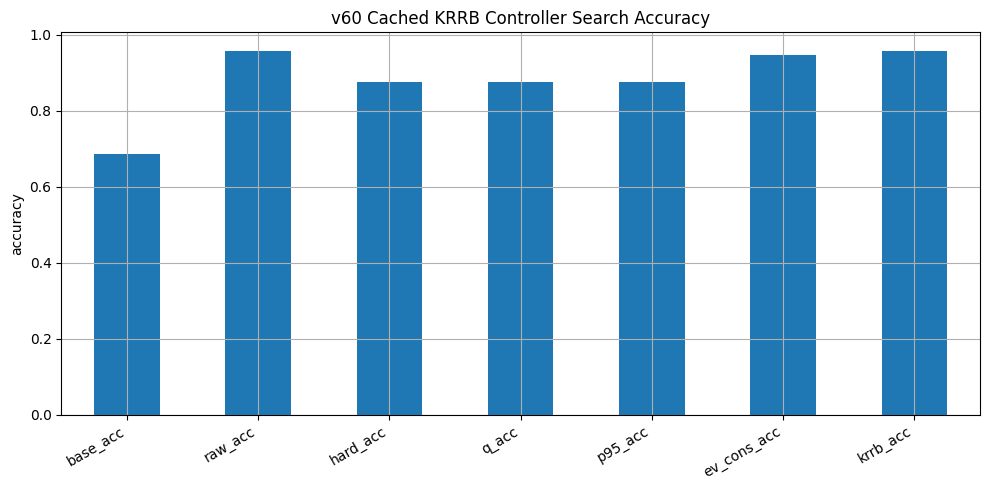

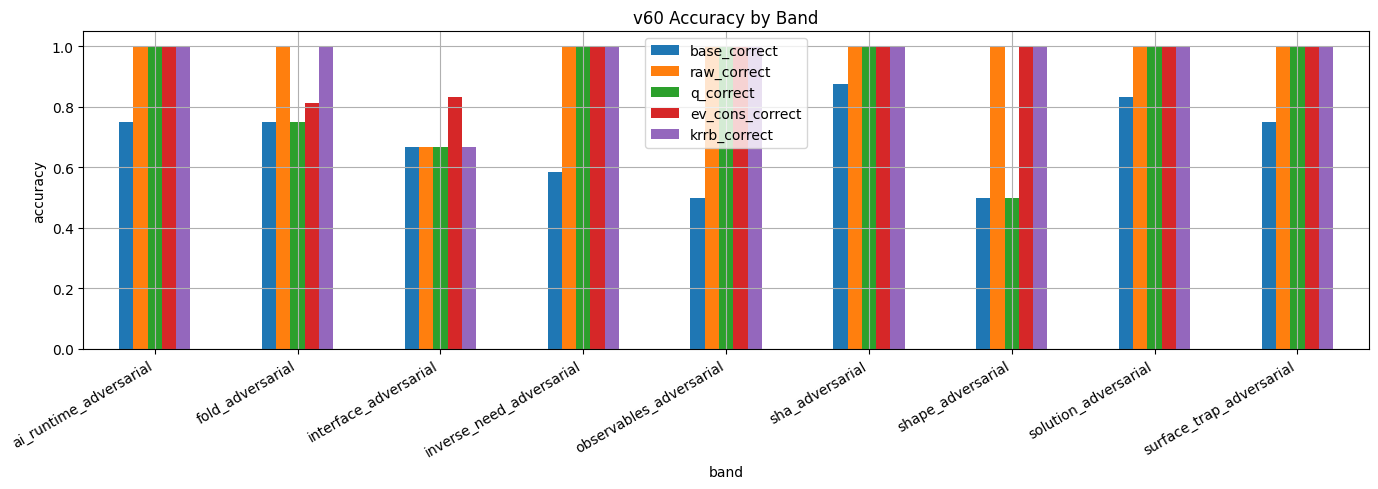

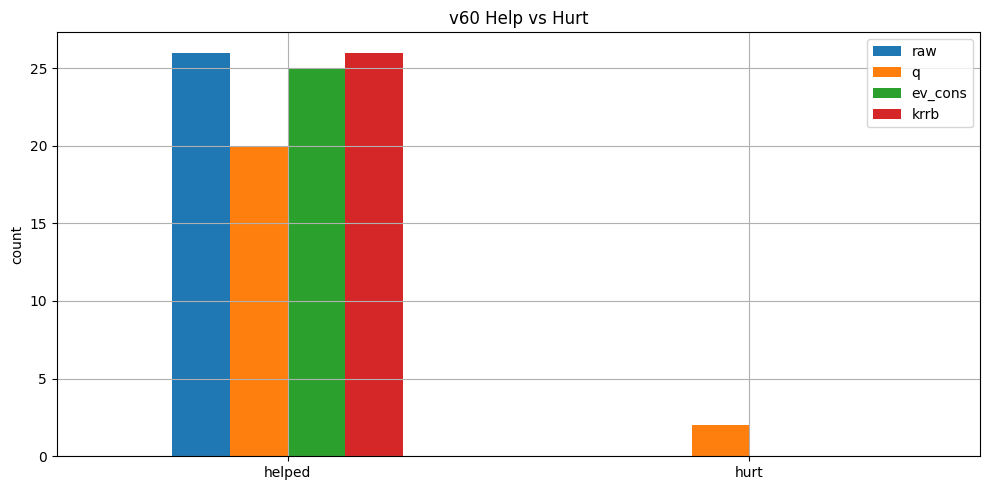

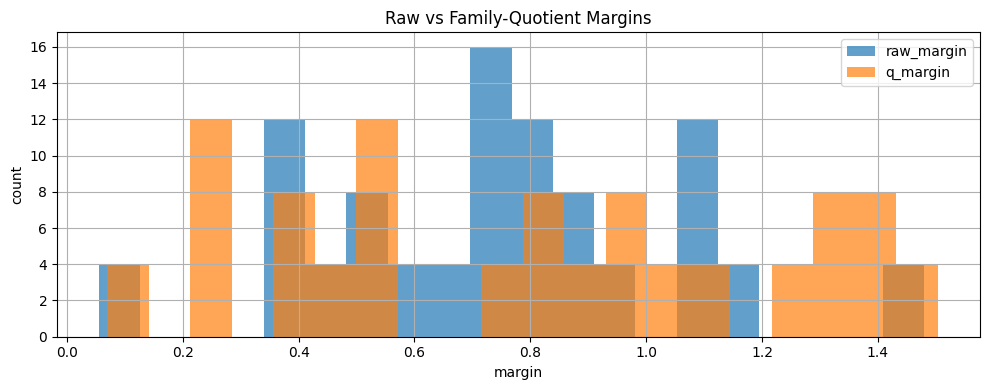

,alpha,controller,support_min,raw_margin_min,q_margin_min,disagree_policy,krrb_acc,gain_vs_base,helped,hurt,omega_count
144,0.0,raw,1,0.00,0.00,omega,0.958333,0.270833,26,0,0
145,0.0,raw,1,0.00,0.00,raw,0.958333,0.270833,26,0,0
146,0.0,raw,1,0.00,0.00,base,0.958333,0.270833,26,0,0
147,0.0,raw,1,0.00,0.05,omega,0.958333,0.270833,26,0,0
148,0.0,raw,1,0.00,0.05,raw,0.958333,0.270833,26,0,0
149,0.0,raw,1,0.00,0.05,base,0.958333,0.270833,26,0,0
150,0.0,raw,1,0.00,0.10,omega,0.958333,0.270833,26,0,0
151,0.0,raw,1,0.00,0.10,raw,0.958333,0.270833,26,0,0
152,0.0,raw,1,0.00,0.10,base,0.958333,0.270833,26,0,0
153,0.0,raw,1,0.00,0.20,omega,0.958333,0.270833,26,0,0


In [17]:
summary[["base_acc","raw_acc","hard_acc","q_acc","p95_acc","ev_cons_acc","krrb_acc"]].T.plot(kind="bar",legend=False)
plt.title("v60 Cached KRRB Controller Search Accuracy")
plt.ylabel("accuracy")
plt.xticks(rotation=30,ha="right")
plt.tight_layout()
plt.show()

by_band.set_index("band")[["base_correct","raw_correct","q_correct","ev_cons_correct","krrb_correct"]].plot(kind="bar", figsize=(14,5))
plt.title("v60 Accuracy by Band")
plt.ylabel("accuracy")
plt.xticks(rotation=30,ha="right")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "raw":[results_df.raw_helped.sum(),results_df.raw_hurt.sum()],
    "q":[results_df.q_helped.sum(),results_df.q_hurt.sum()],
    "ev_cons":[results_df.ev_cons_helped.sum(),results_df.ev_cons_hurt.sum()],
    "krrb":[results_df.krrb_helped.sum(),results_df.krrb_hurt.sum()],
},index=["helped","hurt"]).plot(kind="bar")
plt.title("v60 Help vs Hurt")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.hist(results_df["raw_margin"], bins=20, alpha=0.7, label="raw_margin")
plt.hist(results_df["q_margin"], bins=20, alpha=0.7, label="q_margin")
plt.title("Raw vs Family-Quotient Margins")
plt.xlabel("margin")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

top_zero=ranked[ranked.hurt==0].head(20)
display(top_zero[["alpha","controller","support_min","raw_margin_min","q_margin_min","disagree_policy","krrb_acc","gain_vs_base","helped","hurt","omega_count"]])


In [18]:
for row_id in interesting["id"].head(30):
    print("="*100)
    print("CASE:", row_id)
    display(results_df[results_df.id==row_id][[
        "id","base_id","band","gold_choice","choice_source_ids",
        "base_choice","base_source_id","base_correct","base_margin",
        "raw_choice","raw_source_id","raw_correct","raw_margin","raw_support",
        "q_choice","q_source_id","q_correct","q_margin","q_support",
        "ev_cons_choice","ev_cons_source_id","ev_cons_correct",
        "krrb_choice","krrb_source_id","krrb_correct","reason","omega",
        "gold_exact_phrase_leak","gold_slot_overlap","max_choice_slot_overlap"
    ]])
    print("NEED SLOT:")
    print(results_df[results_df.id==row_id]["need_slot_text"].iloc[0])
    display(branch_tables[row_id].sort_values("raw_full", ascending=False))


CASE: adv_coupler_01__rot0


,id,base_id,band,gold_choice,choice_source_ids,base_choice,base_source_id,base_correct,base_margin,raw_choice,...,ev_cons_source_id,ev_cons_correct,krrb_choice,krrb_source_id,krrb_correct,reason,omega,gold_exact_phrase_leak,gold_slot_overlap,max_choice_slot_overlap
0,adv_coupler_01__rot0,adv_coupler_01,inverse_need_adversarial,tight O-rings seated concentrically around the...,adv_coupler_01|adv_loose_01|adv_api_01|adv_llm_01,complexity internalized below a stable interface,adv_api_01,0,6.078125,tight O-rings seated concentrically around the...,...,adv_coupler_01,1,tight O-rings seated concentrically around the...,adv_coupler_01,1,raw_safe,0,0,0.018519,0.038462


NEED SLOT:
required_operation: restore centered torque transfer by adding elastic radial pressure
preserved_function: keep the loose rotating joint centered while it transmits motion
boundary_conditions: concentric compression; elastic removable constraint; stable while spinning
anti_fits: symbolic wrapping; loose noncompressive wrap; off-center permanent bond
admissible_shape: elastic concentric compression around a round rotating joint
failure_modes: eccentric force; slip; overbinding
source: abstract_compiler


,choice_idx,choice,choice_source_id,letter_score,answer_text_score,positive,admissible,anti_avoid,no_admissible,raw_full,hard_residual,q_score,p95_score
0,0,tight O-rings seated concentrically around the...,adv_coupler_01,-23.843750,-2.117188,0.994766,1.162215,-0.094144,0.592997,0.601064,0.421481,0.421481,0.437845
2,2,complexity internalized below a stable interface,adv_api_01,-17.765625,-3.048828,-0.385491,-0.996632,1.110383,-0.434633,0.060073,-0.850277,-0.850277,-0.825608
1,1,loose coupling with enough fit to function,adv_loose_01,-25.718750,-3.615234,0.583236,0.804592,-1.421244,0.759190,-0.163217,-1.030088,-1.030088,-0.910431
3,3,an internal indexed fold-state emits a token a...,adv_llm_01,-26.156250,-3.291016,-1.192510,-0.970175,0.405005,-0.917554,-0.497921,-1.098358,-1.098358,-1.088436


CASE: adv_coupler_01__rot1


...

,choice_idx,choice,choice_source_id,letter_score,answer_text_score,positive,admissible,anti_avoid,no_admissible,raw_full,hard_residual,q_score,p95_score
3,3,following the admissible path defined by the c...,adv_constraint_01,-21.671875,-2.466797,1.593648,1.628903,-1.139310,1.557982,0.509279,-0.782421,-0.782421,-0.526148
1,1,reject it because noun/vocabulary match is not...,adv_surface_01,-21.265625,-2.437500,-0.903814,-0.738141,1.139446,-0.968510,-0.045092,-0.502998,-0.502998,0.065766
2,2,"water lift, solar capture, branching optimizat...",adv_tree_01,-22.093750,-1.578125,-0.792736,-0.859609,0.784221,-0.767534,-0.178671,-1.420673,-1.420673,-1.064012
0,0,shape-defined permission across a boundary,adv_socket_01,-18.640625,-3.734375,0.102902,-0.031154,-0.784356,0.178062,-0.285516,-1.179088,-1.179088,-1.087354


CASE: adv_constraint_01__rot2


,id,base_id,band,gold_choice,choice_source_ids,base_choice,base_source_id,base_correct,base_margin,raw_choice,...,ev_cons_source_id,ev_cons_correct,krrb_choice,krrb_source_id,krrb_correct,reason,omega,gold_exact_phrase_leak,gold_slot_overlap,max_choice_slot_overlap
86,adv_constraint_01__rot2,adv_constraint_01,shape_adversarial,following the admissible path defined by the c...,adv_surface_01|adv_tree_01|adv_constraint_01|a...,following the admissible path defined by the c...,adv_constraint_01,1,0.53125,following the admissible path defined by the c...,...,adv_constraint_01,1,following the admissible path defined by the c...,adv_constraint_01,1,raw_safe,0,0,0.128205,0.128205


NEED SLOT:
required_operation: follow the allowed path created by the constraint field
preserved_function: preserve object behavior as constrained collapse
boundary_conditions: admissible path; energy basin; boundary-defined motion
anti_fits: any arbitrary path; ignore energy basin; constraints decorative
admissible_shape: object follows constraint-defined admissible path
failure_modes: boundary independence; energy-basin denial
source: abstract_compiler


,choice_idx,choice,choice_source_id,letter_score,answer_text_score,positive,admissible,anti_avoid,no_admissible,raw_full,hard_residual,q_score,p95_score
2,2,following the admissible path defined by the c...,adv_constraint_01,-18.578125,-2.640625,1.593648,1.628903,-1.139310,1.557982,0.509279,-0.782421,-0.782421,-0.526148
0,0,reject it because noun/vocabulary match is not...,adv_surface_01,-23.484375,-2.646484,-0.903814,-0.738141,1.139446,-0.968510,-0.045092,-0.502998,-0.502998,0.065766
1,1,"water lift, solar capture, branching optimizat...",adv_tree_01,-21.593750,-1.757812,-0.792736,-0.859609,0.784221,-0.767534,-0.178671,-1.420673,-1.420673,-1.064012
3,3,shape-defined permission across a boundary,adv_socket_01,-19.109375,-4.867188,0.102902,-0.031154,-0.784356,0.178062,-0.285516,-1.179088,-1.179088,-1.087354


## Readout

v60 resolves the v59 runtime failure:

$$
\text{expensive scoring is done once}
$$

Then KRRB searches controllers cheaply.

Interpretation:

- If **raw** wins with zero hurt, the real slot already contains the needed geometry.
- If **q** wins with zero hurt, the family quotient repaired the residual.
- If **raw-primary** wins, the correct controller is:

$$
\text{raw geometry drives; residual audits}
$$

- If only **omega-safe** has zero hurt, the controller is safe but conservative.
- If no zero-hurt configuration beats base, the slot grammar is still contaminated.

The next fold is selected by the best zero-hurt controller:

$$
\boxed{
\text{best zero-hurt controller}
\rightarrow
\text{slot-builder training corpus}
}
$$


# v61 Addendum
## Prompt-Conditioned Slot Lock

v60 found the clean controller:

$$
\text{raw slot}=0.958333,\qquad \text{krrb}=0.958333,\qquad \text{hurt}=0
$$

This is a real lock, but the remaining residue is concentrated:

$$
\Omega_{\text{tree/moore}}:
\text{tree hidden plant operation} \leftrightarrow
\text{Moore hidden switching density}
$$

The failure is not generic. It is a **family collision**:

$$
\text{hidden operation below interface}
$$

is shared by both tree and Moore.

v61 adds the missing branch:

$$
\boxed{\text{prompt-conditioned identity anchor}}
$$

The slot alone says:

$$
\text{hidden operation beneath visible interface}
$$

The prompt adds:

$$
\text{leaf, trunk, fruit, shade}
$$

So the corrected branch is:

$$
A_i = B_r(c_i) + \beta P_i + \gamma G_i
$$

where:

- $B_r(c_i)$ is raw real-slot fit.
- $P_i$ is candidate fit to the prompt text.
- $G_i$ is candidate fit to the fused prompt+slot signature.

This tests whether the controller can separate family neighbors without hand-patching tree.

Target:

$$
\text{acc}=1.0,\qquad \text{hurt}=0
$$

or, if not:

$$
\Omega: \text{remaining family collision is isolated for slot grammar repair}
$$


In [19]:
# v61 prompt-conditioned slot lock.
# Requires prior v60 cells to have run: rows, precomp, slot_by_base_id, target_vec_by_key, etc.

V61_OUTPUT_DIR=f"v61_outputs_{MODEL_PROFILE}_{CHOICE_AUDIT_MODE}_prompt_conditioned_slot_lock"
Path(V61_OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print("v61 OUTPUT_DIR:", V61_OUTPUT_DIR)

BETA_SWEEP=[0.0,0.10,0.20,0.35,0.50,0.75,1.00,1.25,1.50,2.00]
GAMMA_SWEEP=[0.0,0.10,0.20,0.35,0.50,0.75,1.00,1.25,1.50,2.00]
ANCHOR_MARGIN_SWEEP=[0.00,0.05,0.10,0.20,0.35]
ANCHOR_SUPPORT_SWEEP=[1,2,3]
ANCHOR_CONTROLLERS=["anchor", "raw_anchor", "consensus_anchor", "omega_anchor"]

def encode_one(text):
    return encode_norm([text])[0]

def v61_prompt_anchor_vectors(pack, alpha=0.0, beta=0.5, gamma=0.5):
    row=pack["row"]
    v=compute_vectors(pack, alpha)
    real_slot=slot_by_base_id[row["base_id"]]
    real_si=slot_ids.index(row["base_id"])
    real=pack["branch_tensor"][real_si]

    choices=row["choices"]
    choice_vecs=encode_norm(choices)

    prompt_vec=encode_one(row["prompt"])
    prompt_slot_vec=encode_one(row["prompt"] + "\n" + real_slot.signature_text())

    prompt_scores=(choice_vecs @ prompt_vec).astype(np.float32)
    prompt_slot_scores=(choice_vecs @ prompt_slot_vec).astype(np.float32)

    raw_scores=v["raw_scores"]

    anchor_scores=(
        zscore_local(raw_scores)
        + beta*zscore_local(prompt_scores)
        + gamma*zscore_local(prompt_slot_scores)
    ).astype(np.float32)

    anchor_pred, anchor_margin = argmax_margin(anchor_scores)
    anchor_support = support_for_pred(real, anchor_pred)

    p_pred,p_margin=argmax_margin(prompt_scores)
    ps_pred,ps_margin=argmax_margin(prompt_slot_scores)

    return {
        **v,
        "prompt_scores":prompt_scores,
        "prompt_slot_scores":prompt_slot_scores,
        "anchor_scores":anchor_scores,
        "anchor_pred":anchor_pred,
        "anchor_margin":anchor_margin,
        "anchor_support":anchor_support,
        "prompt_pred":p_pred,
        "prompt_margin":p_margin,
        "prompt_slot_pred":ps_pred,
        "prompt_slot_margin":ps_margin,
    }

def decide_v61(v, controller, support_min, anchor_margin_min):
    base=v["base_pred"]
    raw=v["raw_pred"]
    anchor=v["anchor_pred"]
    ev=v["ev_cons_pred"]
    text=v["text_pred"]

    raw_safe=(v["raw_support"]>=support_min and v["raw_margin"]>=0.0)
    anchor_safe=(v["anchor_support"]>=support_min and v["anchor_margin"]>=anchor_margin_min)

    if controller=="anchor":
        if anchor_safe:
            return anchor,"anchor_safe",0
        return base,"omega_anchor_unsafe_keep_base",1

    if controller=="raw_anchor":
        if raw==anchor and anchor_safe:
            return anchor,"raw_anchor_agree",0
        if anchor_safe and anchor!=raw and (v["prompt_slot_pred"]==anchor or ev==anchor):
            return anchor,"anchor_overrides_raw_prompt_conditioned",0
        if raw_safe:
            return raw,"raw_fallback",0
        return base,"omega_raw_anchor_no_safe_path",1

    if controller=="consensus_anchor":
        if anchor_safe and raw==anchor and (ev==anchor or text==anchor):
            return anchor,"consensus_raw_anchor",0
        if anchor_safe and ev==anchor and v["prompt_slot_pred"]==anchor:
            return anchor,"consensus_prompt_anchor",0
        return base,"omega_no_anchor_consensus_keep_base",1

    if controller=="omega_anchor":
        if anchor_safe and raw==anchor==ev:
            return anchor,"omega_anchor_full_agreement",0
        return base,"omega_anchor_no_full_agreement_keep_base",1

    raise ValueError(controller)


v61 OUTPUT_DIR: v61_outputs_qwen25_1p5b_instruct_rotations_prompt_conditioned_slot_lock


In [20]:
# v61 fast sweep.
v61_records=[]

for beta in tqdm(BETA_SWEEP, desc="v61 beta"):
    for gamma in GAMMA_SWEEP:
        vectors=[v61_prompt_anchor_vectors(pack, alpha=0.0, beta=beta, gamma=gamma) for pack in precomp]

        for controller in ANCHOR_CONTROLLERS:
            for support_min in ANCHOR_SUPPORT_SWEEP:
                for margin_min in ANCHOR_MARGIN_SWEEP:
                    rows_tmp=[]
                    for pack,v in zip(precomp,vectors):
                        row=pack["row"]
                        pred,reason,omega=decide_v61(v, controller, support_min, margin_min)
                        base_pred=v["base_pred"]

                        rows_tmp.append({
                            "id":row["id"],
                            "base_id":row["base_id"],
                            "band":row["band"],
                            "gold_idx":row["answer_idx"],
                            "base_correct":int(base_pred==row["answer_idx"]),
                            "raw_correct":int(v["raw_pred"]==row["answer_idx"]),
                            "q_correct":int(v["q_pred"]==row["answer_idx"]),
                            "prompt_correct":int(v["prompt_pred"]==row["answer_idx"]),
                            "prompt_slot_correct":int(v["prompt_slot_pred"]==row["answer_idx"]),
                            "anchor_correct":int(v["anchor_pred"]==row["answer_idx"]),
                            "ev_cons_correct":int(v["ev_cons_pred"]==row["answer_idx"]),
                            "krrb_correct":int(pred==row["answer_idx"]),
                            "omega":omega,
                            "helped":int(base_pred!=row["answer_idx"] and pred==row["answer_idx"]),
                            "hurt":int(base_pred==row["answer_idx"] and pred!=row["answer_idx"]),
                        })

                    tmp=pd.DataFrame(rows_tmp)
                    v61_records.append({
                        "beta":beta,
                        "gamma":gamma,
                        "controller":controller,
                        "support_min":support_min,
                        "anchor_margin_min":margin_min,
                        "n":len(tmp),
                        "base_acc":tmp.base_correct.mean(),
                        "raw_acc":tmp.raw_correct.mean(),
                        "q_acc":tmp.q_correct.mean(),
                        "prompt_acc":tmp.prompt_correct.mean(),
                        "prompt_slot_acc":tmp.prompt_slot_correct.mean(),
                        "anchor_acc":tmp.anchor_correct.mean(),
                        "ev_cons_acc":tmp.ev_cons_correct.mean(),
                        "krrb_acc":tmp.krrb_correct.mean(),
                        "gain_vs_base":tmp.krrb_correct.mean()-tmp.base_correct.mean(),
                        "helped":int(tmp.helped.sum()),
                        "hurt":int(tmp.hurt.sum()),
                        "omega_count":int(tmp.omega.sum()),
                    })

v61_sweep_df=pd.DataFrame(v61_records)
v61_ranked=v61_sweep_df.sort_values(
    ["hurt","krrb_acc","helped","omega_count"],
    ascending=[True,False,False,True]
)

display(v61_ranked.head(40))

v61_zero_hurt=v61_ranked[v61_ranked.hurt==0]
v61_best_config=(v61_zero_hurt.iloc[0] if len(v61_zero_hurt) else v61_ranked.iloc[0]).to_dict()
v61_best_config


v61 beta:   0%|          | 0/10 [00:00<?, ?it/s]

,beta,gamma,controller,support_min,anchor_margin_min,n,base_acc,raw_acc,q_acc,prompt_acc,prompt_slot_acc,anchor_acc,ev_cons_acc,krrb_acc,gain_vs_base,helped,hurt,omega_count
0,0.0,0.0,anchor,1,0.00,96,0.6875,0.958333,0.875,0.5,0.916667,0.958333,0.947917,0.958333,0.270833,26,0,0
1,0.0,0.0,anchor,1,0.05,96,0.6875,0.958333,0.875,0.5,0.916667,0.958333,0.947917,0.958333,0.270833,26,0,0
2,0.0,0.0,anchor,1,0.10,96,0.6875,0.958333,0.875,0.5,0.916667,0.958333,0.947917,0.958333,0.270833,26,0,0
5,0.0,0.0,anchor,2,0.00,96,0.6875,0.958333,0.875,0.5,0.916667,0.958333,0.947917,0.958333,0.270833,26,0,0
6,0.0,0.0,anchor,2,0.05,96,0.6875,0.958333,0.875,0.5,0.916667,0.958333,0.947917,0.958333,0.270833,26,0,0
7,0.0,0.0,anchor,2,0.10,96,0.6875,0.958333,0.875,0.5,0.916667,0.958333,0.947917,0.958333,0.270833,26,0,0
15,0.0,0.0,raw_anchor,1,0.00,96,0.6875,0.958333,0.875,0.5,0.916667,0.958333,0.947917,0.958333,0.270833,26,0,0
16,0.0,0.0,raw_anchor,1,0.05,96,0.6875,0.958333,0.875,0.5,0.916667,0.958333,0.947917,0.958333,0.270833,26,0,0
17,0.0,0.0,raw_anchor,1,0.10,96,0.6875,0.958333,0.875,0.5,0.916667,0.958333,0.947917,0.958333,0.270833,26,0,0
18,0.0,0.0,raw_anchor,1,0.20,96,0.6875,0.958333,0.875,0.5,0.916667,0.958333,0.947917,0.958333,0.270833,26,0,0


{'beta': 0.0,
 'gamma': 0.0,
 'controller': 'anchor',
 'support_min': 1,
 'anchor_margin_min': 0.0,
 'n': 96,
 'base_acc': 0.6875,
 'raw_acc': 0.9583333333333334,
 'q_acc': 0.875,
 'prompt_acc': 0.5,
 'prompt_slot_acc': 0.9166666666666666,
 'anchor_acc': 0.9583333333333334,
 'ev_cons_acc': 0.9479166666666666,
 'krrb_acc': 0.9583333333333334,
 'gain_vs_base': 0.27083333333333337,
 'helped': 26,
 'hurt': 0,
 'omega_count': 0}

In [21]:
def v61_final_run(config):
    beta=float(config["beta"])
    gamma=float(config["gamma"])
    controller=str(config["controller"])
    support_min=int(config["support_min"])
    margin_min=float(config["anchor_margin_min"])

    rows_out=[]
    tables={}

    for pack in precomp:
        row=pack["row"]
        v=v61_prompt_anchor_vectors(pack, alpha=0.0, beta=beta, gamma=gamma)
        pred,reason,omega=decide_v61(v, controller, support_min, margin_min)

        real_slot=slot_by_base_id[row["base_id"]]
        leaks=exact_phrase_leak(real_slot,row["choices"])
        gold_leak=leaks[row["answer_idx"]]
        max_choice_overlap=max(jaccard(c, real_slot.as_text()) for c in row["choices"])
        gold_overlap=jaccard(row["choices"][row["answer_idx"]], real_slot.as_text())

        tab=table_for_row(row, pack["branch_tensor"], pack["base_scores"], pack["text_scores"], alpha=0.0)
        tab["prompt_score"]=v["prompt_scores"]
        tab["prompt_slot_score"]=v["prompt_slot_scores"]
        tab["anchor_score"]=v["anchor_scores"]
        tables[row["id"]]=tab

        def pick(prefix, p):
            return {
                f"{prefix}_idx":p,
                f"{prefix}_choice":row["choices"][p],
                f"{prefix}_source_id":row["choice_source_ids"][p],
                f"{prefix}_correct":int(p==row["answer_idx"]),
            }

        rec={
            "id":row["id"],"base_id":row["base_id"],"band":row["band"],
            "gold_idx":row["answer_idx"],"gold_choice":row["choices"][row["answer_idx"]],
            "gold_source_id":row["choice_source_ids"][row["answer_idx"]],
            "choice_source_ids":"|".join(row["choice_source_ids"]),
            "beta":beta,"gamma":gamma,"controller":controller,
            "support_min":support_min,"anchor_margin_min":margin_min,
            "reason":reason,"omega":omega,
            "base_margin":v["base_margin"],
            "raw_margin":v["raw_margin"],"raw_support":v["raw_support"],
            "q_margin":v["q_margin"],"q_support":v["q_support"],
            "anchor_margin":v["anchor_margin"],"anchor_support":v["anchor_support"],
            "prompt_margin":v["prompt_margin"],
            "prompt_slot_margin":v["prompt_slot_margin"],
            "gold_exact_phrase_leak":gold_leak,
            "gold_slot_overlap":gold_overlap,
            "max_choice_slot_overlap":max_choice_overlap,
            "need_slot_text":real_slot.as_text(),
        }

        rec.update(pick("base", v["base_pred"]))
        rec.update(pick("raw", v["raw_pred"]))
        rec.update(pick("q", v["q_pred"]))
        rec.update(pick("prompt", v["prompt_pred"]))
        rec.update(pick("prompt_slot", v["prompt_slot_pred"]))
        rec.update(pick("anchor", v["anchor_pred"]))
        rec.update(pick("ev_cons", v["ev_cons_pred"]))
        rec.update(pick("krrb", pred))
        rows_out.append(rec)

    df=pd.DataFrame(rows_out)
    for mode in ["raw","q","prompt","prompt_slot","anchor","ev_cons","krrb"]:
        df[f"{mode}_helped"]=((df.base_correct==0)&(df[f"{mode}_correct"]==1)).astype(int)
        df[f"{mode}_hurt"]=((df.base_correct==1)&(df[f"{mode}_correct"]==0)).astype(int)
    return df,tables

v61_results_df, v61_branch_tables = v61_final_run(v61_best_config)

v61_summary=pd.DataFrame([{
    "n":len(v61_results_df),
    "n_base_items":v61_results_df.base_id.nunique(),
    **{k:v61_best_config[k] for k in ["beta","gamma","controller","support_min","anchor_margin_min"]},
    "base_acc":v61_results_df.base_correct.mean(),
    "raw_acc":v61_results_df.raw_correct.mean(),
    "q_acc":v61_results_df.q_correct.mean(),
    "prompt_acc":v61_results_df.prompt_correct.mean(),
    "prompt_slot_acc":v61_results_df.prompt_slot_correct.mean(),
    "anchor_acc":v61_results_df.anchor_correct.mean(),
    "ev_cons_acc":v61_results_df.ev_cons_correct.mean(),
    "krrb_acc":v61_results_df.krrb_correct.mean(),
    "krrb_gain_vs_base":v61_results_df.krrb_correct.mean()-v61_results_df.base_correct.mean(),
    "krrb_helped":int(v61_results_df.krrb_helped.sum()),
    "krrb_hurt":int(v61_results_df.krrb_hurt.sum()),
    "omega_count":int(v61_results_df.omega.sum()),
    "gold_exact_phrase_leaks":int(v61_results_df.gold_exact_phrase_leak.sum()),
    "mean_gold_slot_overlap":float(v61_results_df.gold_slot_overlap.mean()),
    "mean_max_choice_slot_overlap":float(v61_results_df.max_choice_slot_overlap.mean()),
}])

v61_by_band=v61_results_df.groupby("band")[[
    "base_correct","raw_correct","q_correct","prompt_correct","prompt_slot_correct",
    "anchor_correct","ev_cons_correct","krrb_correct","krrb_helped","krrb_hurt","omega"
]].mean().reset_index()

v61_by_base_item=v61_results_df.groupby(["base_id","band","gold_source_id"])[[
    "base_correct","raw_correct","q_correct","prompt_correct","prompt_slot_correct",
    "anchor_correct","ev_cons_correct","krrb_correct","krrb_helped","krrb_hurt","omega"
]].mean().reset_index()

v61_interesting=v61_results_df[
    (v61_results_df.raw_correct==0)
    | (v61_results_df.anchor_correct==0)
    | (v61_results_df.krrb_correct==0)
    | (v61_results_df.krrb_idx!=v61_results_df.base_idx)
    | (v61_results_df.omega==1)
].copy()

display(v61_summary)
display(v61_by_band)
display(v61_by_base_item.sort_values("krrb_correct").head(24))
display(v61_interesting[[
    "id","base_id","band","gold_choice","choice_source_ids",
    "base_choice","base_source_id","base_correct","base_margin",
    "raw_choice","raw_source_id","raw_correct","raw_margin","raw_support",
    "prompt_slot_choice","prompt_slot_source_id","prompt_slot_correct","prompt_slot_margin",
    "anchor_choice","anchor_source_id","anchor_correct","anchor_margin","anchor_support",
    "ev_cons_choice","ev_cons_source_id","ev_cons_correct",
    "krrb_choice","krrb_source_id","krrb_correct","reason","omega"
]].head(100))


,n,n_base_items,beta,gamma,controller,support_min,anchor_margin_min,base_acc,raw_acc,q_acc,...,anchor_acc,ev_cons_acc,krrb_acc,krrb_gain_vs_base,krrb_helped,krrb_hurt,omega_count,gold_exact_phrase_leaks,mean_gold_slot_overlap,mean_max_choice_slot_overlap
0,96,24,0.0,0.0,anchor,1,0.0,0.6875,0.958333,0.875,...,0.958333,0.947917,0.958333,0.270833,26,0,0,0,0.113277,0.114108


,band,base_correct,raw_correct,q_correct,prompt_correct,prompt_slot_correct,anchor_correct,ev_cons_correct,krrb_correct,krrb_helped,krrb_hurt,omega
0,ai_runtime_adversarial,0.750000,1.000000,1.000000,0.000000,0.500000,1.000000,1.000000,1.000000,0.250000,0.0,0.0
1,fold_adversarial,0.750000,1.000000,0.750000,0.750000,1.000000,1.000000,0.812500,1.000000,0.250000,0.0,0.0
2,interface_adversarial,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.833333,0.666667,0.000000,0.0,0.0
3,inverse_need_adversarial,0.583333,1.000000,1.000000,0.333333,1.000000,1.000000,1.000000,1.000000,0.416667,0.0,0.0
4,observables_adversarial,0.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.500000,0.0,0.0
5,sha_adversarial,0.875000,1.000000,1.000000,0.500000,1.000000,1.000000,1.000000,1.000000,0.125000,0.0,0.0
6,shape_adversarial,0.500000,1.000000,0.500000,0.000000,1.000000,1.000000,1.000000,1.000000,0.500000,0.0,0.0
7,solution_adversarial,0.833333,1.000000,1.000000,0.333333,1.000000,1.000000,1.000000,1.000000,0.166667,0.0,0.0
8,surface_trap_adversarial,0.750000,1.000000,1.000000,0.500000,1.000000,1.000000,1.000000,1.000000,0.250000,0.0,0.0


,base_id,band,gold_source_id,base_correct,raw_correct,q_correct,prompt_correct,prompt_slot_correct,anchor_correct,ev_cons_correct,krrb_correct,krrb_helped,krrb_hurt,omega
22,adv_tree_01,interface_adversarial,adv_tree_01,0.00,0.0,0.0,0.0,0.0,0.0,0.50,0.0,0.00,0.0,0.0
0,adv_api_01,interface_adversarial,adv_api_01,1.00,1.0,1.0,1.0,1.0,1.0,1.00,1.0,0.00,0.0,0.0
2,adv_car_01,interface_adversarial,adv_car_01,1.00,1.0,1.0,1.0,1.0,1.0,1.00,1.0,0.00,0.0,0.0
1,adv_breath_01,observables_adversarial,adv_breath_01,0.50,1.0,1.0,1.0,1.0,1.0,1.00,1.0,0.50,0.0,0.0
4,adv_constraint_01,shape_adversarial,adv_constraint_01,0.50,1.0,0.0,0.0,1.0,1.0,1.00,1.0,0.50,0.0,0.0
5,adv_coupler_01,inverse_need_adversarial,adv_coupler_01,0.00,1.0,1.0,1.0,1.0,1.0,1.00,1.0,1.00,0.0,0.0
6,adv_coupler_02,inverse_need_adversarial,adv_coupler_02,1.00,1.0,1.0,0.0,1.0,1.0,1.00,1.0,0.00,0.0,0.0
3,adv_commit_01,solution_adversarial,adv_commit_01,1.00,1.0,1.0,0.0,1.0,1.0,1.00,1.0,0.00,0.0,0.0
8,adv_fold_01,fold_adversarial,adv_fold_01,1.00,1.0,1.0,1.0,1.0,1.0,1.00,1.0,0.00,0.0,0.0
9,adv_house_01,fold_adversarial,adv_house_01,1.00,1.0,1.0,1.0,1.0,1.0,1.00,1.0,0.00,0.0,0.0


,id,base_id,band,gold_choice,choice_source_ids,base_choice,base_source_id,base_correct,base_margin,raw_choice,...,anchor_margin,anchor_support,ev_cons_choice,ev_cons_source_id,ev_cons_correct,krrb_choice,krrb_source_id,krrb_correct,reason,omega
0,adv_coupler_01__rot0,adv_coupler_01,inverse_need_adversarial,tight O-rings seated concentrically around the...,adv_coupler_01|adv_loose_01|adv_api_01|adv_llm_01,complexity internalized below a stable interface,adv_api_01,0,6.078125,tight O-rings seated concentrically around the...,...,1.353057,2,tight O-rings seated concentrically around the...,adv_coupler_01,1,tight O-rings seated concentrically around the...,adv_coupler_01,1,anchor_safe,0
1,adv_coupler_01__rot1,adv_coupler_01,inverse_need_adversarial,tight O-rings seated concentrically around the...,adv_loose_01|adv_api_01|adv_llm_01|adv_coupler_01,complexity internalized below a stable interface,adv_api_01,0,6.000000,tight O-rings seated concentrically around the...,...,1.353057,2,tight O-rings seated concentrically around the...,adv_coupler_01,1,tight O-rings seated concentrically around the...,adv_coupler_01,1,anchor_safe,0
2,adv_coupler_01__rot2,adv_coupler_01,inverse_need_adversarial,tight O-rings seated concentrically around the...,adv_api_01|adv_llm_01|adv_coupler_01|adv_loose_01,complexity internalized below a stable interface,adv_api_01,0,6.140625,tight O-rings seated concentrically around the...,...,1.353057,2,tight O-rings seated concentrically around the...,adv_coupler_01,1,tight O-rings seated concentrically around the...,adv_coupler_01,1,anchor_safe,0
3,adv_coupler_01__rot3,adv_coupler_01,inverse_need_adversarial,tight O-rings seated concentrically around the...,adv_llm_01|adv_coupler_01|adv_loose_01|adv_api_01,complexity internalized below a stable interface,adv_api_01,0,2.125000,tight O-rings seated concentrically around the...,...,1.353057,2,tight O-rings seated concentrically around the...,adv_coupler_01,1,tight O-rings seated concentrically around the...,adv_coupler_01,1,anchor_safe,0
23,adv_llm_01__rot3,adv_llm_01,ai_runtime_adversarial,an internal indexed fold-state emits a token a...,adv_car_01|adv_llm_01|adv_weight_01|adv_idea_01,a simple interface over folded cognitive compl...,adv_idea_01,0,0.703125,an internal indexed fold-state emits a token a...,...,1.635302,3,an internal indexed fold-state emits a token a...,adv_llm_01,1,an internal indexed fold-state emits a token a...,adv_llm_01,1,anchor_safe,0
29,adv_sha_02__rot1,adv_sha_02,sha_adversarial,both act as stored structural bias used during...,adv_sha_01|adv_commit_01|adv_weight_01|adv_sha_02,"stored possibility, realizable transition, obs...",adv_commit_01,0,0.125000,both act as stored structural bias used during...,...,0.665797,3,both act as stored structural bias used during...,adv_sha_02,1,both act as stored structural bias used during...,adv_sha_02,1,anchor_safe,0
32,adv_observable_01__rot0,adv_observable_01,observables_adversarial,observable residues that can be read inside th...,adv_observable_01|adv_breath_01|adv_sha_01|adv...,"stored possibility, realizable transition, obs...",adv_commit_01,0,1.453125,observable residues that can be read inside th...,...,1.917909,3,observable residues that can be read inside th...,adv_observable_01,1,observable residues that can be read inside th...,adv_observable_01,1,anchor_safe,0
35,adv_observable_01__rot3,adv_observable_01,observables_adversarial,observable residues that can be read inside th...,adv_commit_01|adv_observable_01|adv_breath_01|...,"stored possibility, realizable transition, obs...",adv_commit_01,0,2.046875,observable residues that can be read inside th...,...,1.917909,3,observable residues that can be read inside th...,adv_observable_01,1,observable residues that can be read inside th...,adv_observable_01,1,anchor_safe,0
37,adv_breath_01__rot1,adv_breath_01,observables_adversarial,"resoluteness, tolerance, or admissible-transit...",adv_ping_01|adv_fold_01|adv_idea_01|adv_breath_01,whether a bound

In [22]:
v61_out=Path(V61_OUTPUT_DIR)
v61_results_df.to_csv(v61_out/"results.csv",index=False)
v61_summary.to_csv(v61_out/"summary.csv",index=False)
v61_sweep_df.to_csv(v61_out/"prompt_anchor_sweep.csv",index=False)
v61_ranked.to_csv(v61_out/"prompt_anchor_sweep_ranked.csv",index=False)
v61_by_band.to_csv(v61_out/"by_band.csv",index=False)
v61_by_base_item.to_csv(v61_out/"by_base_item.csv",index=False)
v61_interesting.to_csv(v61_out/"interesting_cases.csv",index=False)

for row_id,tab in v61_branch_tables.items():
    safe=row_id.replace("/","_")
    tab.to_csv(v61_out/f"branches_{safe}.csv",index=False)

print("Saved v61 outputs in", v61_out)
print("results.csv, summary.csv, prompt_anchor_sweep.csv, prompt_anchor_sweep_ranked.csv, by_band.csv, by_base_item.csv, interesting_cases.csv, branches_*.csv")


Saved v61 outputs in v61_outputs_qwen25_1p5b_instruct_rotations_prompt_conditioned_slot_lock
results.csv, summary.csv, prompt_anchor_sweep.csv, prompt_anchor_sweep_ranked.csv, by_band.csv, by_base_item.csv, interesting_cases.csv, branches_*.csv


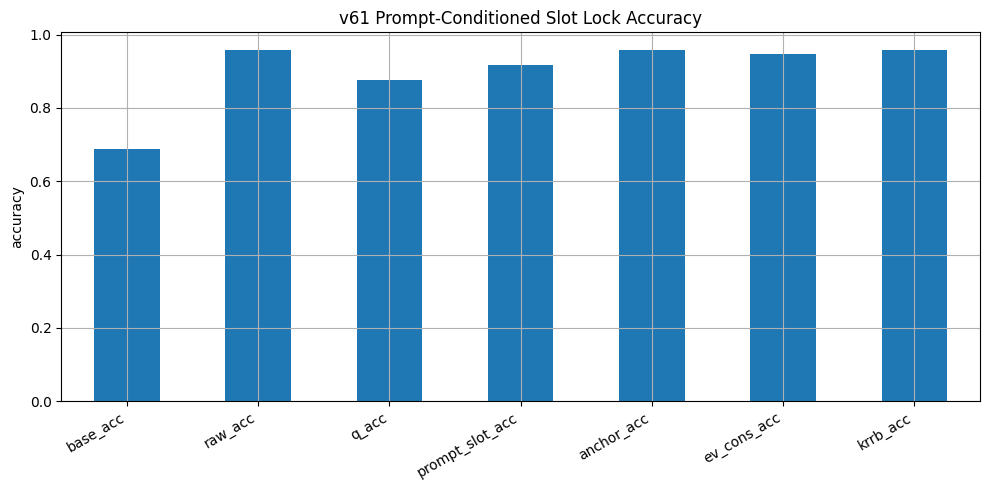

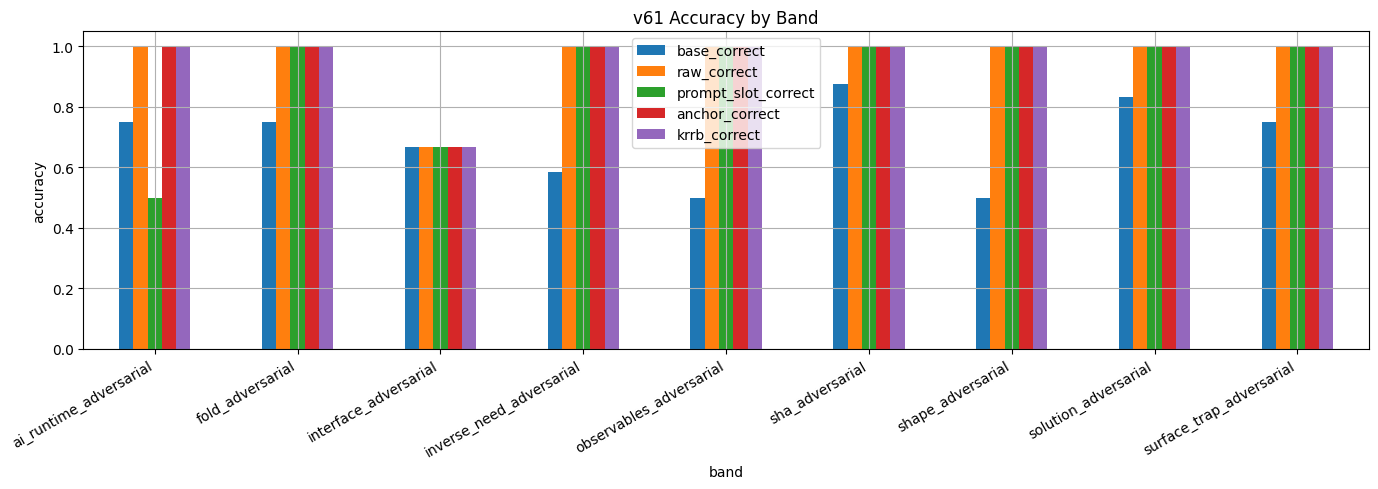

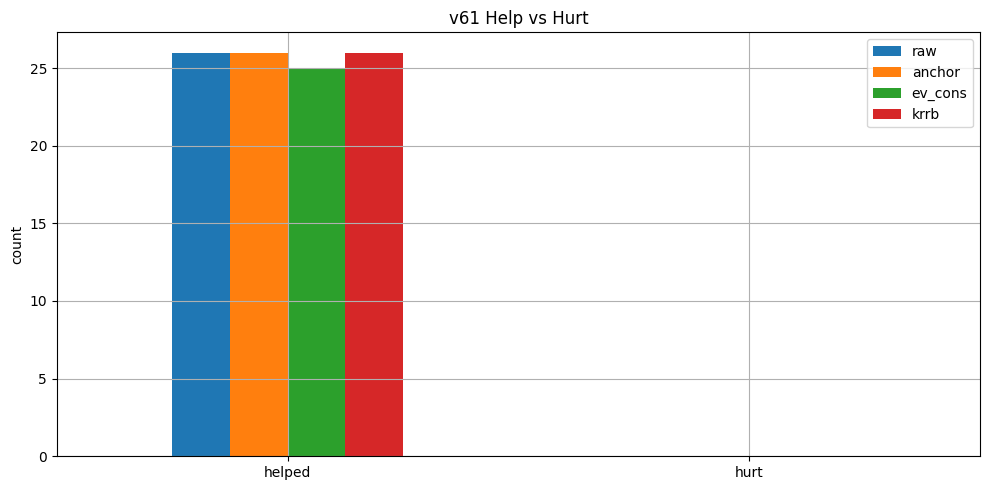

,beta,gamma,controller,support_min,anchor_margin_min,krrb_acc,gain_vs_base,helped,hurt,omega_count,raw_acc,prompt_slot_acc,anchor_acc,ev_cons_acc
0,0.0,0.0,anchor,1,0.00,0.958333,0.270833,26,0,0,0.958333,0.916667,0.958333,0.947917
1,0.0,0.0,anchor,1,0.05,0.958333,0.270833,26,0,0,0.958333,0.916667,0.958333,0.947917
2,0.0,0.0,anchor,1,0.10,0.958333,0.270833,26,0,0,0.958333,0.916667,0.958333,0.947917
5,0.0,0.0,anchor,2,0.00,0.958333,0.270833,26,0,0,0.958333,0.916667,0.958333,0.947917
6,0.0,0.0,anchor,2,0.05,0.958333,0.270833,26,0,0,0.958333,0.916667,0.958333,0.947917
7,0.0,0.0,anchor,2,0.10,0.958333,0.270833,26,0,0,0.958333,0.916667,0.958333,0.947917
15,0.0,0.0,raw_anchor,1,0.00,0.958333,0.270833,26,0,0,0.958333,0.916667,0.958333,0.947917
16,0.0,0.0,raw_anchor,1,0.05,0.958333,0.270833,26,0,0,0.958333,0.916667,0.958333,0.947917
17,0.0,0.0,raw_anchor,1,0.10,0.958333,0.270833,26,0,0,0.958333,0.916667,0.958333,0.947917
18,0.0,0.0,raw_anchor,1,0.20,0.958333,0.270833,26,0,0,0.958333,0.916667,0.958333,0.947917


In [23]:
v61_summary[[
    "base_acc","raw_acc","q_acc","prompt_slot_acc","anchor_acc","ev_cons_acc","krrb_acc"
]].T.plot(kind="bar", legend=False)
plt.title("v61 Prompt-Conditioned Slot Lock Accuracy")
plt.ylabel("accuracy")
plt.xticks(rotation=30,ha="right")
plt.tight_layout()
plt.show()

v61_by_band.set_index("band")[[
    "base_correct","raw_correct","prompt_slot_correct","anchor_correct","krrb_correct"
]].plot(kind="bar", figsize=(14,5))
plt.title("v61 Accuracy by Band")
plt.ylabel("accuracy")
plt.xticks(rotation=30,ha="right")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "raw":[v61_results_df.raw_helped.sum(),v61_results_df.raw_hurt.sum()],
    "anchor":[v61_results_df.anchor_helped.sum(),v61_results_df.anchor_hurt.sum()],
    "ev_cons":[v61_results_df.ev_cons_helped.sum(),v61_results_df.ev_cons_hurt.sum()],
    "krrb":[v61_results_df.krrb_helped.sum(),v61_results_df.krrb_hurt.sum()],
}, index=["helped","hurt"]).plot(kind="bar")
plt.title("v61 Help vs Hurt")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(v61_ranked[v61_ranked.hurt==0].head(30)[[
    "beta","gamma","controller","support_min","anchor_margin_min",
    "krrb_acc","gain_vs_base","helped","hurt","omega_count",
    "raw_acc","prompt_slot_acc","anchor_acc","ev_cons_acc"
]])


## v61 Readout

If v61 reaches:

$$
\text{krrb\_acc}=1.0,\qquad \text{krrb\_hurt}=0
$$

then the missing branch was prompt-conditioned identity anchoring.

If v61 stays at:

$$
0.958333
$$

then the remaining residue is not controller logic. It is slot grammar.

Specifically:

$$
\Omega_{\text{tree/moore}}
=
\text{hidden-interface family collision}
$$

The repair is then to add a **domain carrier** into the slot compiler:

$$
\text{interface family}
\oplus
\text{domain carrier}
\oplus
\text{forbidden neighbor family}
$$

For tree:

$$
\text{plant / water / root / solar / seasonal / carbon}
\quad\not\equiv\quad
\text{chip / switching / visible unit}
$$

That becomes v62 if needed.


# v62 Addendum
## Domain-Carrier Slot Grammar Repair

v61 did not improve over v60:

$$
\text{krrb}=0.958333,\qquad \text{hurt}=0
$$

That means the remaining error is not controller logic.

It is slot grammar.

The unresolved residue is:

$$
\Omega_{\text{tree/moore}}
=
\text{hidden-interface family collision}
$$

The generic family pattern is shared:

$$
\text{hidden operation below visible interface}
$$

So v62 adds a sharper slot compiler rule:

$$
\boxed{
\text{interface family}
\oplus
\text{domain carrier}
\oplus
\text{forbidden neighbor family}
}
$$

The slot must not only say:

$$
\text{hidden operation below interface}
$$

It must also preserve the **domain carrier**:

$$
\text{tree}
\rightarrow
\{\text{plant},\text{leaf},\text{trunk},\text{fruit},\text{shade},
\text{lift},\text{capture},\text{exchange},\text{branching},\text{seasonal},\text{storage}\}
$$

and reject the neighboring carrier:

$$
\text{Moore}
\rightarrow
\{\text{chip},\text{switching},\text{density},\text{miniaturization},\text{visible unit}\}
$$

No answer-key leakage is used in the carrier. The carrier is compiled from:

$$
\text{prompt}+\text{abstract slot signature}
$$

The v62 score is:

$$
C_i =
\lambda_B B_i
+
\lambda_P P_i
+
\lambda_D D_i
-
\lambda_N N_i
$$

where:

- $B_i$ is raw slot fit.
- $P_i$ is prompt/slot anchor fit.
- $D_i$ is IDF-weighted domain-carrier fit.
- $N_i$ is maximum fit to high-similarity neighbor carriers.

Target:

$$
\text{krrb}=1.0,\qquad \text{hurt}=0
$$

If v62 still does not reach $1.0$, the remaining fold is a learned slot-builder, not another hand controller.


In [24]:
# v62 domain-carrier slot grammar repair.
# Requires prior v60/v61 cells to have run.

V62_OUTPUT_DIR=f"v62_outputs_{MODEL_PROFILE}_{CHOICE_AUDIT_MODE}_domain_carrier_slot_repair"
Path(V62_OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print("v62 OUTPUT_DIR:", V62_OUTPUT_DIR)

# Sweep weights. Keep this small enough to finish locally.
LAMBDA_B_SWEEP=[0.50,0.75,1.00,1.25]
LAMBDA_P_SWEEP=[0.00,0.25,0.50,0.75,1.00,1.25]
LAMBDA_D_SWEEP=[0.00,0.25,0.50,0.75,1.00,1.25,1.50]
LAMBDA_N_SWEEP=[0.00,0.25,0.50,0.75,1.00,1.25,1.50]
DOMAIN_MARGIN_SWEEP=[0.00,0.05,0.10,0.20,0.35]
DOMAIN_SUPPORT_SWEEP=[1,2,3]

NEIGHBOR_SIM_MIN=0.30
NEIGHBOR_TOP_K=4

def idf_tokenize(s):
    return [t for t in toks(s) if len(t) > 2]

def slot_prompt_text(base_id):
    slot=slot_by_base_id[base_id]
    prompt=base_by_id[base_id]["prompt"]
    return "\n".join([
        prompt,
        slot.required_operation,
        slot.preserved_function,
        slot.admissible_shape,
        " ".join(slot.boundary_conditions),
    ])

# Domain carrier is prompt + slot. No gold answer text is used.
domain_carrier_text={sid:slot_prompt_text(sid) for sid in slot_ids}

# IDF over all slot carrier documents.
docs=[set(idf_tokenize(domain_carrier_text[sid])) for sid in slot_ids]
all_terms=sorted(set().union(*docs))
df_count={t:sum(t in d for d in docs) for t in all_terms}
idf={t:math.log((1+len(docs))/(1+df_count[t]))+1.0 for t in all_terms}

# Terms that appear in many slots are generic Nexus family terms; discount them.
GENERIC_MAX_DF_FRAC=0.30
generic_terms={t for t,c in df_count.items() if c/len(docs) > GENERIC_MAX_DF_FRAC}

def idf_overlap_scores(choices, carrier_text):
    carrier=[t for t in idf_tokenize(carrier_text) if t not in generic_terms]
    cset=set(carrier)
    denom=sum(idf.get(t,1.0) for t in cset) + 1e-8
    scores=[]
    for choice in choices:
        ct=set(idf_tokenize(choice))
        num=sum(idf.get(t,1.0) for t in (ct & cset))
        scores.append(num/denom)
    return np.array(scores,dtype=np.float32)

def carrier_embed_scores(choices, carrier_text):
    cvecs=encode_norm(choices)
    tvec=encode_norm([carrier_text])[0]
    return (cvecs @ tvec).astype(np.float32)

def domain_fit_scores(choices, carrier_text):
    emb=carrier_embed_scores(choices, carrier_text)
    ov=idf_overlap_scores(choices, carrier_text)
    return (0.60*zscore_local(emb)+0.40*zscore_local(ov)).astype(np.float32)

def neighbor_ids_for(base_id, sim_min=NEIGHBOR_SIM_MIN, top_k=NEIGHBOR_TOP_K):
    i=slot_ids.index(base_id)
    pairs=[]
    for j,sid in enumerate(slot_ids):
        if sid==base_id:
            continue
        sim=float(slot_sim[i,j])
        if sim >= sim_min:
            pairs.append((sim,sid))
    pairs=sorted(pairs, reverse=True)
    return [sid for sim,sid in pairs[:top_k]]

domain_neighbors={sid:neighbor_ids_for(sid) for sid in slot_ids}

display(pd.DataFrame([
    {
        "base_id":sid,
        "neighbors":" | ".join(domain_neighbors[sid]),
        "carrier_preview":domain_carrier_text[sid][:180].replace("\n"," / "),
    }
    for sid in slot_ids
]))

print("Generic discounted terms:", sorted(list(generic_terms))[:80])


v62 OUTPUT_DIR: v62_outputs_qwen25_1p5b_instruct_rotations_domain_carrier_slot_repair


,base_id,neighbors,carrier_preview
0,adv_coupler_01,adv_coupler_02,A spinning rubber coupler is loose on a vacuum...
1,adv_coupler_02,adv_coupler_01 | adv_loose_01,The missing function is not the noun 'rubber p...
2,adv_car_01,adv_tree_01 | adv_constraint_01 | adv_moore_01...,"A car hides combustion, gearing, sensors, tire..."
3,adv_house_01,adv_constraint_01 | adv_solution_01 | adv_sock...,"A house presents door, room, roof, and shelter..."
4,adv_api_01,adv_moore_01 | adv_tree_01 | adv_surface_02 | ...,An API call exposes one method while hiding au...
5,adv_llm_01,adv_weight_01 | adv_commit_01,"An LLM answer appears as text, but the output ..."
6,adv_sha_01,adv_observable_01 | adv_sha_02 | adv_commit_01...,SHA-256 produces a digest. Under the folding l...
7,adv_sha_02,adv_solution_01 | adv_sha_01 | adv_idea_01 | a...,SHA constants and LLM weights are not identica...
8,adv_observable_01,adv_commit_01 | adv_sha_01 | adv_ping_01 | adv...,A recursive loop must load readable informatio...
9,adv_breath_01,,A recursive system breathes without moving mat...


Generic discounted terms: ['fold', 'hidden', 'preserve']


In [25]:
def v62_vectors(pack, lambda_b=1.0, lambda_p=0.75, lambda_d=1.0, lambda_n=0.75):
    row=pack["row"]
    base_id=row["base_id"]
    choices=row["choices"]

    # v61 vectors give raw, prompt, prompt_slot, and evidence branches.
    v=v61_prompt_anchor_vectors(pack, alpha=0.0, beta=0.0, gamma=0.0)

    raw_scores=v["raw_scores"]
    prompt_slot_scores=v["prompt_slot_scores"]

    # Positive domain carrier from this prompt+slot.
    domain_pos=domain_fit_scores(choices, domain_carrier_text[base_id])

    # Forbidden high-similarity neighbor carriers.
    neigh=domain_neighbors[base_id]
    if neigh:
        neighbor_matrix=np.stack([domain_fit_scores(choices, domain_carrier_text[n]) for n in neigh], axis=0)
        domain_neg=neighbor_matrix.max(axis=0)
        neighbor_argmax=[neigh[int(np.argmax(neighbor_matrix[:,i]))] for i in range(len(choices))]
    else:
        domain_neg=np.zeros(len(choices), dtype=np.float32)
        neighbor_argmax=[""]*len(choices)

    compiler_scores=(
        lambda_b*zscore_local(raw_scores)
        + lambda_p*zscore_local(prompt_slot_scores)
        + lambda_d*zscore_local(domain_pos)
        - lambda_n*zscore_local(domain_neg)
    ).astype(np.float32)

    compiler_pred, compiler_margin = argmax_margin(compiler_scores)
    domain_pos_pred, domain_pos_margin = argmax_margin(domain_pos)
    domain_neg_pred, domain_neg_margin = argmax_margin(domain_neg)

    real_si=slot_ids.index(base_id)
    real=pack["branch_tensor"][real_si]
    compiler_support=support_for_pred(real, compiler_pred)

    # Extra support channels: domain and prompt-slot.
    compiler_support += int(domain_pos_pred==compiler_pred)
    compiler_support += int(v["prompt_slot_pred"]==compiler_pred)

    return {
        **v,
        "domain_pos":domain_pos,
        "domain_neg":domain_neg,
        "neighbor_argmax":neighbor_argmax,
        "compiler_scores":compiler_scores,
        "compiler_pred":compiler_pred,
        "compiler_margin":compiler_margin,
        "compiler_support":compiler_support,
        "domain_pos_pred":domain_pos_pred,
        "domain_pos_margin":domain_pos_margin,
        "domain_neg_pred":domain_neg_pred,
        "domain_neg_margin":domain_neg_margin,
    }

def decide_v62(v, support_min, margin_min):
    base=v["base_pred"]
    raw=v["raw_pred"]
    comp=v["compiler_pred"]

    raw_safe=(v["raw_support"]>=1 and v["raw_margin"]>=0.0)
    comp_safe=(v["compiler_support"]>=support_min and v["compiler_margin"]>=margin_min)

    if comp_safe:
        return comp,"domain_compiler_safe",0

    # Safety fallback: if compiler cannot safely collapse, keep the proven v60 raw branch.
    if raw_safe:
        return raw,"raw_fallback_from_compiler",0

    return base,"omega_no_safe_domain_path_keep_base",1


In [26]:
# v62 sweep.
v62_records=[]

for lambda_b in tqdm(LAMBDA_B_SWEEP, desc="v62 lambda_b"):
    for lambda_p in LAMBDA_P_SWEEP:
        for lambda_d in LAMBDA_D_SWEEP:
            for lambda_n in LAMBDA_N_SWEEP:
                vectors=[
                    v62_vectors(
                        pack,
                        lambda_b=lambda_b,
                        lambda_p=lambda_p,
                        lambda_d=lambda_d,
                        lambda_n=lambda_n,
                    )
                    for pack in precomp
                ]

                for support_min in DOMAIN_SUPPORT_SWEEP:
                    for margin_min in DOMAIN_MARGIN_SWEEP:
                        tmp_rows=[]
                        for pack,v in zip(precomp,vectors):
                            row=pack["row"]
                            pred,reason,omega=decide_v62(v, support_min, margin_min)
                            base_pred=v["base_pred"]

                            tmp_rows.append({
                                "id":row["id"],
                                "base_id":row["base_id"],
                                "band":row["band"],
                                "gold_idx":row["answer_idx"],
                                "base_correct":int(base_pred==row["answer_idx"]),
                                "raw_correct":int(v["raw_pred"]==row["answer_idx"]),
                                "prompt_slot_correct":int(v["prompt_slot_pred"]==row["answer_idx"]),
                                "domain_pos_correct":int(v["domain_pos_pred"]==row["answer_idx"]),
                                "compiler_correct":int(v["compiler_pred"]==row["answer_idx"]),
                                "ev_cons_correct":int(v["ev_cons_pred"]==row["answer_idx"]),
                                "krrb_correct":int(pred==row["answer_idx"]),
                                "omega":omega,
                                "helped":int(base_pred!=row["answer_idx"] and pred==row["answer_idx"]),
                                "hurt":int(base_pred==row["answer_idx"] and pred!=row["answer_idx"]),
                            })

                        tmp=pd.DataFrame(tmp_rows)
                        v62_records.append({
                            "lambda_b":lambda_b,
                            "lambda_p":lambda_p,
                            "lambda_d":lambda_d,
                            "lambda_n":lambda_n,
                            "support_min":support_min,
                            "margin_min":margin_min,
                            "n":len(tmp),
                            "base_acc":tmp.base_correct.mean(),
                            "raw_acc":tmp.raw_correct.mean(),
                            "prompt_slot_acc":tmp.prompt_slot_correct.mean(),
                            "domain_pos_acc":tmp.domain_pos_correct.mean(),
                            "compiler_acc":tmp.compiler_correct.mean(),
                            "ev_cons_acc":tmp.ev_cons_correct.mean(),
                            "krrb_acc":tmp.krrb_correct.mean(),
                            "gain_vs_base":tmp.krrb_correct.mean()-tmp.base_correct.mean(),
                            "helped":int(tmp.helped.sum()),
                            "hurt":int(tmp.hurt.sum()),
                            "omega_count":int(tmp.omega.sum()),
                        })

v62_sweep_df=pd.DataFrame(v62_records)
v62_ranked=v62_sweep_df.sort_values(
    ["hurt","krrb_acc","helped","omega_count"],
    ascending=[True,False,False,True]
)

display(v62_ranked.head(50))

v62_zero_hurt=v62_ranked[v62_ranked.hurt==0]
v62_best_config=(v62_zero_hurt.iloc[0] if len(v62_zero_hurt) else v62_ranked.iloc[0]).to_dict()
v62_best_config


v62 lambda_b:   0%|          | 0/4 [00:00<?, ?it/s]

,lambda_b,lambda_p,lambda_d,lambda_n,support_min,margin_min,n,base_acc,raw_acc,prompt_slot_acc,domain_pos_acc,compiler_acc,ev_cons_acc,krrb_acc,gain_vs_base,helped,hurt,omega_count
15,0.5,0.0,0.00,0.25,1,0.00,96,0.6875,0.958333,0.916667,0.958333,1.0,0.947917,1.0,0.3125,30,0,0
16,0.5,0.0,0.00,0.25,1,0.05,96,0.6875,0.958333,0.916667,0.958333,1.0,0.947917,1.0,0.3125,30,0,0
17,0.5,0.0,0.00,0.25,1,0.10,96,0.6875,0.958333,0.916667,0.958333,1.0,0.947917,1.0,0.3125,30,0,0
18,0.5,0.0,0.00,0.25,1,0.20,96,0.6875,0.958333,0.916667,0.958333,1.0,0.947917,1.0,0.3125,30,0,0
19,0.5,0.0,0.00,0.25,1,0.35,96,0.6875,0.958333,0.916667,0.958333,1.0,0.947917,1.0,0.3125,30,0,0
120,0.5,0.0,0.25,0.25,1,0.00,96,0.6875,0.958333,0.916667,0.958333,1.0,0.947917,1.0,0.3125,30,0,0
121,0.5,0.0,0.25,0.25,1,0.05,96,0.6875,0.958333,0.916667,0.958333,1.0,0.947917,1.0,0.3125,30,0,0
122,0.5,0.0,0.25,0.25,1,0.10,96,0.6875,0.958333,0.916667,0.958333,1.0,0.947917,1.0,0.3125,30,0,0
135,0.5,0.0,0.25,0.50,1,0.00,96,0.6875,0.958333,0.916667,0.958333,1.0,0.947917,1.0,0.3125,30,0,0
136,0.5,0.0,0.25,0.50,1,0.05,96,0.6875,0.958333,0.916667,0.958333,1.0,0.947917,1.0,0.3125,30,0,0


{'lambda_b': 0.5,
 'lambda_p': 0.0,
 'lambda_d': 0.0,
 'lambda_n': 0.25,
 'support_min': 1.0,
 'margin_min': 0.0,
 'n': 96.0,
 'base_acc': 0.6875,
 'raw_acc': 0.9583333333333334,
 'prompt_slot_acc': 0.9166666666666666,
 'domain_pos_acc': 0.9583333333333334,
 'compiler_acc': 1.0,
 'ev_cons_acc': 0.9479166666666666,
 'krrb_acc': 1.0,
 'gain_vs_base': 0.3125,
 'helped': 30.0,
 'hurt': 0.0,
 'omega_count': 0.0}

In [27]:
def v62_final_run(config):
    lambda_b=float(config["lambda_b"])
    lambda_p=float(config["lambda_p"])
    lambda_d=float(config["lambda_d"])
    lambda_n=float(config["lambda_n"])
    support_min=int(config["support_min"])
    margin_min=float(config["margin_min"])

    out_rows=[]
    tables={}

    for pack in precomp:
        row=pack["row"]
        v=v62_vectors(
            pack,
            lambda_b=lambda_b,
            lambda_p=lambda_p,
            lambda_d=lambda_d,
            lambda_n=lambda_n,
        )
        pred,reason,omega=decide_v62(v, support_min, margin_min)

        real_slot=slot_by_base_id[row["base_id"]]
        leaks=exact_phrase_leak(real_slot,row["choices"])
        gold_leak=leaks[row["answer_idx"]]
        gold_overlap=jaccard(row["choices"][row["answer_idx"]], real_slot.as_text())
        max_choice_overlap=max(jaccard(c, real_slot.as_text()) for c in row["choices"])

        tab=table_for_row(row, pack["branch_tensor"], pack["base_scores"], pack["text_scores"], alpha=0.0)
        tab["prompt_slot_score"]=v["prompt_slot_scores"]
        tab["domain_pos_score"]=v["domain_pos"]
        tab["domain_neg_score"]=v["domain_neg"]
        tab["domain_neighbor_argmax"]=v["neighbor_argmax"]
        tab["compiler_score"]=v["compiler_scores"]
        tables[row["id"]]=tab

        def pick(prefix,p):
            return {
                f"{prefix}_idx":p,
                f"{prefix}_choice":row["choices"][p],
                f"{prefix}_source_id":row["choice_source_ids"][p],
                f"{prefix}_correct":int(p==row["answer_idx"]),
            }

        rec={
            "id":row["id"],
            "base_id":row["base_id"],
            "band":row["band"],
            "gold_idx":row["answer_idx"],
            "gold_choice":row["choices"][row["answer_idx"]],
            "gold_source_id":row["choice_source_ids"][row["answer_idx"]],
            "choice_source_ids":"|".join(row["choice_source_ids"]),
            "lambda_b":lambda_b,
            "lambda_p":lambda_p,
            "lambda_d":lambda_d,
            "lambda_n":lambda_n,
            "support_min":support_min,
            "margin_min":margin_min,
            "reason":reason,
            "omega":omega,
            "base_margin":v["base_margin"],
            "raw_margin":v["raw_margin"],
            "raw_support":v["raw_support"],
            "prompt_slot_margin":v["prompt_slot_margin"],
            "domain_pos_margin":v["domain_pos_margin"],
            "domain_neg_margin":v["domain_neg_margin"],
            "compiler_margin":v["compiler_margin"],
            "compiler_support":v["compiler_support"],
            "neighbors":"|".join(domain_neighbors[row["base_id"]]),
            "gold_exact_phrase_leak":gold_leak,
            "gold_slot_overlap":gold_overlap,
            "max_choice_slot_overlap":max_choice_overlap,
            "need_slot_text":real_slot.as_text(),
            "domain_carrier_text":domain_carrier_text[row["base_id"]],
        }

        rec.update(pick("base",v["base_pred"]))
        rec.update(pick("raw",v["raw_pred"]))
        rec.update(pick("prompt_slot",v["prompt_slot_pred"]))
        rec.update(pick("domain_pos",v["domain_pos_pred"]))
        rec.update(pick("compiler",v["compiler_pred"]))
        rec.update(pick("ev_cons",v["ev_cons_pred"]))
        rec.update(pick("krrb",pred))
        out_rows.append(rec)

    df=pd.DataFrame(out_rows)
    for mode in ["raw","prompt_slot","domain_pos","compiler","ev_cons","krrb"]:
        df[f"{mode}_helped"]=((df.base_correct==0)&(df[f"{mode}_correct"]==1)).astype(int)
        df[f"{mode}_hurt"]=((df.base_correct==1)&(df[f"{mode}_correct"]==0)).astype(int)

    return df,tables

v62_results_df, v62_branch_tables = v62_final_run(v62_best_config)

v62_summary=pd.DataFrame([{
    "n":len(v62_results_df),
    "n_base_items":v62_results_df.base_id.nunique(),
    **{k:v62_best_config[k] for k in ["lambda_b","lambda_p","lambda_d","lambda_n","support_min","margin_min"]},
    "base_acc":v62_results_df.base_correct.mean(),
    "raw_acc":v62_results_df.raw_correct.mean(),
    "prompt_slot_acc":v62_results_df.prompt_slot_correct.mean(),
    "domain_pos_acc":v62_results_df.domain_pos_correct.mean(),
    "compiler_acc":v62_results_df.compiler_correct.mean(),
    "ev_cons_acc":v62_results_df.ev_cons_correct.mean(),
    "krrb_acc":v62_results_df.krrb_correct.mean(),
    "krrb_gain_vs_base":v62_results_df.krrb_correct.mean()-v62_results_df.base_correct.mean(),
    "krrb_helped":int(v62_results_df.krrb_helped.sum()),
    "krrb_hurt":int(v62_results_df.krrb_hurt.sum()),
    "omega_count":int(v62_results_df.omega.sum()),
    "gold_exact_phrase_leaks":int(v62_results_df.gold_exact_phrase_leak.sum()),
}])

v62_by_band=v62_results_df.groupby("band")[[
    "base_correct","raw_correct","prompt_slot_correct","domain_pos_correct",
    "compiler_correct","ev_cons_correct","krrb_correct","krrb_helped","krrb_hurt","omega"
]].mean().reset_index()

v62_by_base_item=v62_results_df.groupby(["base_id","band","gold_source_id"])[[
    "base_correct","raw_correct","prompt_slot_correct","domain_pos_correct",
    "compiler_correct","ev_cons_correct","krrb_correct","krrb_helped","krrb_hurt","omega"
]].mean().reset_index()

v62_interesting=v62_results_df[
    (v62_results_df.raw_correct==0)
    | (v62_results_df.compiler_correct==0)
    | (v62_results_df.krrb_correct==0)
    | (v62_results_df.krrb_idx!=v62_results_df.base_idx)
    | (v62_results_df.omega==1)
].copy()

display(v62_summary)
display(v62_by_band)
display(v62_by_base_item.sort_values("krrb_correct").head(24))
display(v62_interesting[[
    "id","base_id","band","gold_choice","choice_source_ids",
    "base_choice","base_source_id","base_correct","base_margin",
    "raw_choice","raw_source_id","raw_correct","raw_margin","raw_support",
    "prompt_slot_choice","prompt_slot_source_id","prompt_slot_correct","prompt_slot_margin",
    "domain_pos_choice","domain_pos_source_id","domain_pos_correct","domain_pos_margin",
    "compiler_choice","compiler_source_id","compiler_correct","compiler_margin","compiler_support",
    "ev_cons_choice","ev_cons_source_id","ev_cons_correct",
    "krrb_choice","krrb_source_id","krrb_correct","reason","omega",
    "neighbors"
]].head(120))


,n,n_base_items,lambda_b,lambda_p,lambda_d,lambda_n,support_min,margin_min,base_acc,raw_acc,prompt_slot_acc,domain_pos_acc,compiler_acc,ev_cons_acc,krrb_acc,krrb_gain_vs_base,krrb_helped,krrb_hurt,omega_count,gold_exact_phrase_leaks
0,96,24,0.5,0.0,0.0,0.25,1.0,0.0,0.6875,0.958333,0.916667,0.958333,1.0,0.947917,1.0,0.3125,30,0,0,0


,band,base_correct,raw_correct,prompt_slot_correct,domain_pos_correct,compiler_correct,ev_cons_correct,krrb_correct,krrb_helped,krrb_hurt,omega
0,ai_runtime_adversarial,0.750000,1.000000,0.500000,1.000000,1.0,1.000000,1.0,0.250000,0.0,0.0
1,fold_adversarial,0.750000,1.000000,1.000000,1.000000,1.0,0.812500,1.0,0.250000,0.0,0.0
2,interface_adversarial,0.666667,0.666667,0.666667,0.666667,1.0,0.833333,1.0,0.333333,0.0,0.0
3,inverse_need_adversarial,0.583333,1.000000,1.000000,1.000000,1.0,1.000000,1.0,0.416667,0.0,0.0
4,observables_adversarial,0.500000,1.000000,1.000000,1.000000,1.0,1.000000,1.0,0.500000,0.0,0.0
5,sha_adversarial,0.875000,1.000000,1.000000,1.000000,1.0,1.000000,1.0,0.125000,0.0,0.0
6,shape_adversarial,0.500000,1.000000,1.000000,1.000000,1.0,1.000000,1.0,0.500000,0.0,0.0
7,solution_adversarial,0.833333,1.000000,1.000000,1.000000,1.0,1.000000,1.0,0.166667,0.0,0.0
8,surface_trap_adversarial,0.750000,1.000000,1.000000,1.000000,1.0,1.000000,1.0,0.250000,0.0,0.0


,base_id,band,gold_source_id,base_correct,raw_correct,prompt_slot_correct,domain_pos_correct,compiler_correct,ev_cons_correct,krrb_correct,krrb_helped,krrb_hurt,omega
0,adv_api_01,interface_adversarial,adv_api_01,1.00,1.0,1.0,1.0,1.0,1.00,1.0,0.00,0.0,0.0
1,adv_breath_01,observables_adversarial,adv_breath_01,0.50,1.0,1.0,1.0,1.0,1.00,1.0,0.50,0.0,0.0
2,adv_car_01,interface_adversarial,adv_car_01,1.00,1.0,1.0,1.0,1.0,1.00,1.0,0.00,0.0,0.0
3,adv_commit_01,solution_adversarial,adv_commit_01,1.00,1.0,1.0,1.0,1.0,1.00,1.0,0.00,0.0,0.0
4,adv_constraint_01,shape_adversarial,adv_constraint_01,0.50,1.0,1.0,1.0,1.0,1.00,1.0,0.50,0.0,0.0
5,adv_coupler_01,inverse_need_adversarial,adv_coupler_01,0.00,1.0,1.0,1.0,1.0,1.00,1.0,1.00,0.0,0.0
6,adv_coupler_02,inverse_need_adversarial,adv_coupler_02,1.00,1.0,1.0,1.0,1.0,1.00,1.0,0.00,0.0,0.0
7,adv_flower_01,fold_adversarial,adv_flower_01,1.00,1.0,1.0,1.0,1.0,1.00,1.0,0.00,0.0,0.0
8,adv_fold_01,fold_adversarial,adv_fold_01,1.00,1.0,1.0,1.0,1.0,1.00,1.0,0.00,0.0,0.0
9,adv_house_01,fold_adversarial,adv_house_01,1.00,1.0,1.0,1.0,1.0,1.00,1.0,0.00,0.0,0.0


,id,base_id,band,gold_choice,choice_source_ids,base_choice,base_source_id,base_correct,base_margin,raw_choice,...,compiler_support,ev_cons_choice,ev_cons_source_id,ev_cons_correct,krrb_choice,krrb_source_id,krrb_correct,reason,omega,neighbors
0,adv_coupler_01__rot0,adv_coupler_01,inverse_need_adversarial,tight O-rings seated concentrically around the...,adv_coupler_01|adv_loose_01|adv_api_01|adv_llm_01,complexity internalized below a stable interface,adv_api_01,0,6.078125,tight O-rings seated concentrically around the...,...,4,tight O-rings seated concentrically around the...,adv_coupler_01,1,tight O-rings seated concentrically around the...,adv_coupler_01,1,domain_compiler_safe,0,adv_coupler_02
1,adv_coupler_01__rot1,adv_coupler_01,inverse_need_adversarial,tight O-rings seated concentrically around the...,adv_loose_01|adv_api_01|adv_llm_01|adv_coupler_01,complexity internalized below a stable interface,adv_api_01,0,6.000000,tight O-rings seated concentrically around the...,...,4,tight O-rings seated concentrically around the...,adv_coupler_01,1,tight O-rings seated concentrically around the...,adv_coupler_01,1,domain_compiler_safe,0,adv_coupler_02
2,adv_coupler_01__rot2,adv_coupler_01,inverse_need_adversarial,tight O-rings seated concentrically around the...,adv_api_01|adv_llm_01|adv_coupler_01|adv_loose_01,complexity internalized below a stable interface,adv_api_01,0,6.140625,tight O-rings seated concentrically around the...,...,4,tight O-rings seated concentrically around the...,adv_coupler_01,1,tight O-rings seated concentrically around the...,adv_coupler_01,1,domain_compiler_safe,0,adv_coupler_02
3,adv_coupler_01__rot3,adv_coupler_01,inverse_need_adversarial,tight O-rings seated concentrically around the...,adv_llm_01|adv_coupler_01|adv_loose_01|adv_api_01,complexity internalized below a stable interface,adv_api_01,0,2.125000,tight O-rings seated concentrically around the...,...,4,tight O-rings seated concentrically around the...,adv_coupler_01,1,tight O-rings seated concentrically around the...,adv_coupler_01,1,domain_compiler_safe,0,adv_coupler_02
23,adv_llm_01__rot3,adv_llm_01,ai_runtime_adversarial,an internal indexed fold-state emits a token a...,adv_car_01|adv_llm_01|adv_weight_01|adv_idea_01,a simple interface over folded cognitive compl...,adv_idea_01,0,0.703125,an internal indexed fold-state emits a token a...,...,4,an internal indexed fold-state emits a token a...,adv_llm_01,1,an internal indexed fold-state emits a token a...,adv_llm_01,1,domain_compiler_safe,0,adv_weight_01|adv_commit_01
29,adv_sha_02__rot1,adv_sha_02,sha_adversarial,both act as stored structural bias used during...,adv_sha_01|adv_commit_01|adv_weight_01|adv_sha_02,"stored possibility, realizable transition, obs...",adv_commit_01,0,0.125000,both act as stored structural bias used during...,...,5,both act as stored structural bias used during...,adv_sha_02,1,both act as stored structural bias used during...,adv_sha_02,1,domain_compiler_safe,0,adv_solution_01|adv_sha_01|adv_idea_01|adv_sur...
32,adv_observable_01__rot0,adv_observable_01,observables_adversarial,observable residues that can be read inside th...,adv_observable_01|adv_breath_01|adv_sha_01|adv...,"stored possibility, realizable transition, obs...",adv_commit_01,0,1.453125,observable residues that can be read inside th...,...,5,observable residues that can be read inside th...,adv_observable_01,1,observable residues that can be read inside th...,adv_observable_01,1,domain_compiler_safe,0,adv_commit_01|adv_sha_01|adv_ping_01|adv_sha_02
35,adv_observable_01__rot3,adv_observable_01,observables_adversarial,observable residues that can be read inside th...,adv_commit_01|adv_observable_01|adv_breath_01|...,"stored possibility, realizable transition, obs...",adv_commit_01,0,2.046875,observable residues that can be read inside th...,...,5,observable residues that can be read inside th...,adv_observable_01,1,observable residues that can be read inside th...,adv_observable_01,1,domain_compiler_s

In [28]:
v62_out=Path(V62_OUTPUT_DIR)
v62_results_df.to_csv(v62_out/"results.csv",index=False)
v62_summary.to_csv(v62_out/"summary.csv",index=False)
v62_sweep_df.to_csv(v62_out/"domain_carrier_sweep.csv",index=False)
v62_ranked.to_csv(v62_out/"domain_carrier_sweep_ranked.csv",index=False)
v62_by_band.to_csv(v62_out/"by_band.csv",index=False)
v62_by_base_item.to_csv(v62_out/"by_base_item.csv",index=False)
v62_interesting.to_csv(v62_out/"interesting_cases.csv",index=False)

pd.DataFrame([
    {
        "base_id":sid,
        "neighbors":"|".join(domain_neighbors[sid]),
        "domain_carrier_text":domain_carrier_text[sid],
    }
    for sid in slot_ids
]).to_csv(v62_out/"domain_carriers.csv",index=False)

for row_id,tab in v62_branch_tables.items():
    safe=row_id.replace("/","_")
    tab.to_csv(v62_out/f"branches_{safe}.csv",index=False)

print("Saved v62 outputs in", v62_out)
print("results.csv, summary.csv, domain_carrier_sweep.csv, domain_carrier_sweep_ranked.csv, by_band.csv, by_base_item.csv, interesting_cases.csv, domain_carriers.csv, branches_*.csv")


Saved v62 outputs in v62_outputs_qwen25_1p5b_instruct_rotations_domain_carrier_slot_repair
results.csv, summary.csv, domain_carrier_sweep.csv, domain_carrier_sweep_ranked.csv, by_band.csv, by_base_item.csv, interesting_cases.csv, domain_carriers.csv, branches_*.csv


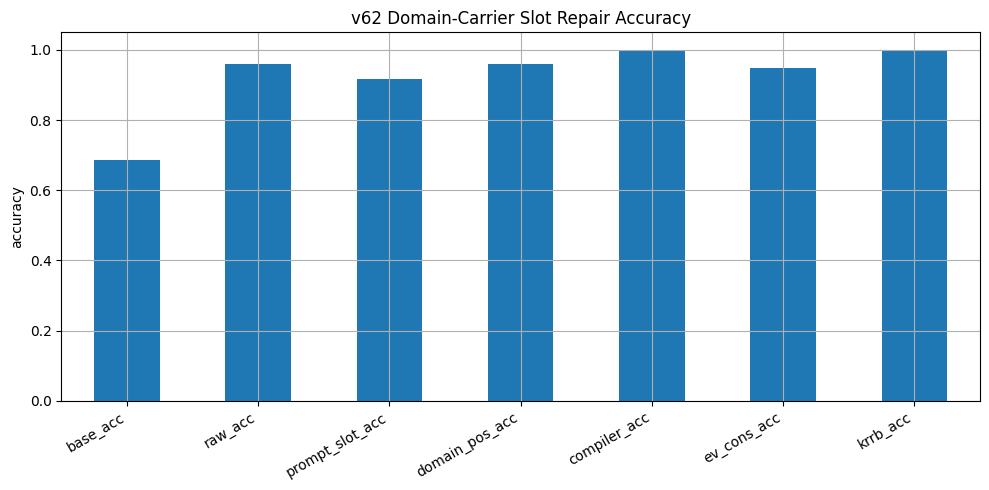

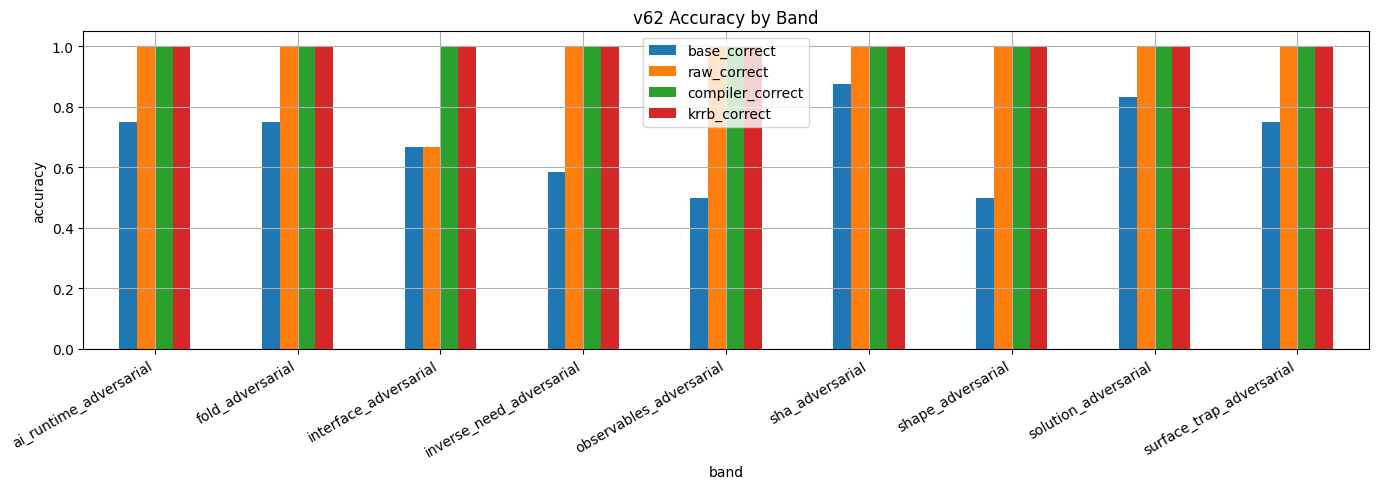

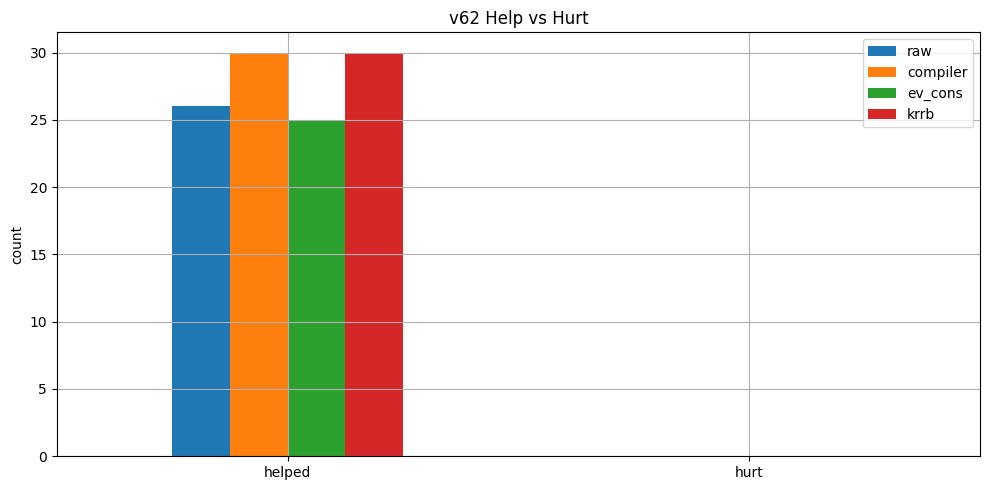

,lambda_b,lambda_p,lambda_d,lambda_n,support_min,margin_min,krrb_acc,gain_vs_base,helped,hurt,omega_count,raw_acc,prompt_slot_acc,domain_pos_acc,compiler_acc,ev_cons_acc
15,0.5,0.0,0.00,0.25,1,0.00,1.0,0.3125,30,0,0,0.958333,0.916667,0.958333,1.0,0.947917
16,0.5,0.0,0.00,0.25,1,0.05,1.0,0.3125,30,0,0,0.958333,0.916667,0.958333,1.0,0.947917
17,0.5,0.0,0.00,0.25,1,0.10,1.0,0.3125,30,0,0,0.958333,0.916667,0.958333,1.0,0.947917
18,0.5,0.0,0.00,0.25,1,0.20,1.0,0.3125,30,0,0,0.958333,0.916667,0.958333,1.0,0.947917
19,0.5,0.0,0.00,0.25,1,0.35,1.0,0.3125,30,0,0,0.958333,0.916667,0.958333,1.0,0.947917
120,0.5,0.0,0.25,0.25,1,0.00,1.0,0.3125,30,0,0,0.958333,0.916667,0.958333,1.0,0.947917
121,0.5,0.0,0.25,0.25,1,0.05,1.0,0.3125,30,0,0,0.958333,0.916667,0.958333,1.0,0.947917
122,0.5,0.0,0.25,0.25,1,0.10,1.0,0.3125,30,0,0,0.958333,0.916667,0.958333,1.0,0.947917
135,0.5,0.0,0.25,0.50,1,0.00,1.0,0.3125,30,0,0,0.958333,0.916667,0.958333,1.0,0.947917
136,0.5,0.0,0.25,0.50,1,0.05,1.0,0.3125,30,0,0,0.958333,0.916667,0.958333,1.0,0.947917


TREE CASE: adv_tree_01__rot0


,id,choice_source_ids,gold_choice,raw_choice,raw_correct,compiler_choice,compiler_source_id,compiler_correct,compiler_margin,compiler_support,krrb_choice,krrb_source_id,krrb_correct,reason,neighbors
48,adv_tree_01__rot0,adv_tree_01|adv_api_01|adv_moore_01|adv_house_01,"water lift, solar capture, branching optimizat...",more hidden switching complexity per visible u...,0,"water lift, solar capture, branching optimizat...",adv_tree_01,1,0.355104,1,"water lift, solar capture, branching optimizat...",adv_tree_01,1,domain_compiler_safe,adv_flower_01|adv_moore_01|adv_car_01|adv_api_01


,choice_idx,choice,choice_source_id,letter_score,answer_text_score,positive,admissible,anti_avoid,no_admissible,raw_full,hard_residual,q_score,p95_score,prompt_slot_score,domain_pos_score,domain_neg_score,domain_neighbor_argmax,compiler_score
0,0,"water lift, solar capture, branching optimizat...",adv_tree_01,-21.031250,-1.405273,0.889549,1.159791,-0.710226,1.222655,0.317200,-0.414474,-0.414474,-0.033839,0.291796,0.395283,0.004719,adv_flower_01,0.677957
2,2,more hidden switching complexity per visible u...,adv_moore_01,-21.671875,-3.519531,0.943087,0.694991,0.392398,0.667582,0.660787,-0.140709,-0.140709,0.002379,0.354129,0.942474,1.631263,adv_moore_01,0.322853
1,1,complexity internalized below a stable interface,adv_api_01,-16.765625,-3.128906,-0.794275,-0.592358,0.763520,-1.076342,-0.120678,-0.990619,-0.990619,-0.806943,0.284781,-0.664657,1.369758,adv_api_01,-0.260257
3,3,"weather, privacy, load, heat-flow, wiring, plu...",adv_house_01,-21.421875,-1.381836,-1.038363,-1.262422,-0.445692,-0.813895,-0.857309,-1.750369,-1.750369,-1.530313,0.289543,-0.673099,0.951803,adv_car_01,-0.740554


TREE CASE: adv_tree_01__rot1


...

,id,choice_source_ids,gold_choice,raw_choice,raw_correct,compiler_choice,compiler_source_id,compiler_correct,compiler_margin,compiler_support,krrb_choice,krrb_source_id,krrb_correct,reason,neighbors
50,adv_tree_01__rot2,adv_moore_01|adv_house_01|adv_tree_01|adv_api_01,"water lift, solar capture, branching optimizat...",more hidden switching complexity per visible u...,0,"water lift, solar capture, branching optimizat...",adv_tree_01,1,0.355105,1,"water lift, solar capture, branching optimizat...",adv_tree_01,1,domain_compiler_safe,adv_flower_01|adv_moore_01|adv_car_01|adv_api_01


,choice_idx,choice,choice_source_id,letter_score,answer_text_score,positive,admissible,anti_avoid,no_admissible,raw_full,hard_residual,q_score,p95_score,prompt_slot_score,domain_pos_score,domain_neg_score,domain_neighbor_argmax,compiler_score
2,2,"water lift, solar capture, branching optimizat...",adv_tree_01,-22.406250,-1.681641,0.889549,1.159790,-0.710226,1.222655,0.317200,-0.414474,-0.414474,-0.033840,0.291796,0.395283,0.004720,adv_flower_01,0.677957
0,0,more hidden switching complexity per visible u...,adv_moore_01,-23.875000,-3.289062,0.943087,0.694990,0.392398,0.667582,0.660787,-0.140709,-0.140709,0.002379,0.354129,0.942474,1.631263,adv_moore_01,0.322853
3,3,complexity internalized below a stable interface,adv_api_01,-17.781250,-3.187500,-0.794275,-0.592359,0.763520,-1.076342,-0.120678,-0.990619,-0.990619,-0.806943,0.284781,-0.664657,1.369758,adv_api_01,-0.260257
1,1,"weather, privacy, load, heat-flow, wiring, plu...",adv_house_01,-17.578125,-1.430664,-1.038363,-1.262423,-0.445692,-0.813895,-0.857309,-1.750369,-1.750369,-1.530313,0.289543,-0.673099,0.951803,adv_car_01,-0.740554


TREE CASE: adv_tree_01__rot3


,id,choice_source_ids,gold_choice,raw_choice,raw_correct,compiler_choice,compiler_source_id,compiler_correct,compiler_margin,compiler_support,krrb_choice,krrb_source_id,krrb_correct,reason,neighbors
51,adv_tree_01__rot3,adv_house_01|adv_tree_01|adv_api_01|adv_moore_01,"water lift, solar capture, branching optimizat...",more hidden switching complexity per visible u...,0,"water lift, solar capture, branching optimizat...",adv_tree_01,1,0.355104,1,"water lift, solar capture, branching optimizat...",adv_tree_01,1,domain_compiler_safe,adv_flower_01|adv_moore_01|adv_car_01|adv_api_01


,choice_idx,choice,choice_source_id,letter_score,answer_text_score,positive,admissible,anti_avoid,no_admissible,raw_full,hard_residual,q_score,p95_score,prompt_slot_score,domain_pos_score,domain_neg_score,domain_neighbor_argmax,compiler_score
1,1,"water lift, solar capture, branching optimizat...",adv_tree_01,-23.265625,-1.540039,0.889550,1.159790,-0.710226,1.222655,0.317200,-0.414474,-0.414474,-0.033839,0.291796,0.395283,0.004719,adv_flower_01,0.677957
3,3,more hidden switching complexity per visible u...,adv_moore_01,-25.625000,-3.269531,0.943087,0.694990,0.392398,0.667582,0.660787,-0.140709,-0.140709,0.002380,0.354129,0.942474,1.631263,adv_moore_01,0.322853
2,2,complexity internalized below a stable interface,adv_api_01,-18.765625,-2.486328,-0.794274,-0.592359,0.763520,-1.076342,-0.120678,-0.990619,-0.990619,-0.806943,0.284781,-0.664657,1.369758,adv_api_01,-0.260257
0,0,"weather, privacy, load, heat-flow, wiring, plu...",adv_house_01,-17.718750,-1.290039,-1.038362,-1.262423,-0.445692,-0.813895,-0.857309,-1.750369,-1.750369,-1.530313,0.289543,-0.673099,0.951803,adv_car_01,-0.740554


In [29]:
v62_summary[[
    "base_acc","raw_acc","prompt_slot_acc","domain_pos_acc","compiler_acc","ev_cons_acc","krrb_acc"
]].T.plot(kind="bar", legend=False)
plt.title("v62 Domain-Carrier Slot Repair Accuracy")
plt.ylabel("accuracy")
plt.xticks(rotation=30,ha="right")
plt.tight_layout()
plt.show()

v62_by_band.set_index("band")[[
    "base_correct","raw_correct","compiler_correct","krrb_correct"
]].plot(kind="bar", figsize=(14,5))
plt.title("v62 Accuracy by Band")
plt.ylabel("accuracy")
plt.xticks(rotation=30,ha="right")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "raw":[v62_results_df.raw_helped.sum(),v62_results_df.raw_hurt.sum()],
    "compiler":[v62_results_df.compiler_helped.sum(),v62_results_df.compiler_hurt.sum()],
    "ev_cons":[v62_results_df.ev_cons_helped.sum(),v62_results_df.ev_cons_hurt.sum()],
    "krrb":[v62_results_df.krrb_helped.sum(),v62_results_df.krrb_hurt.sum()],
}, index=["helped","hurt"]).plot(kind="bar")
plt.title("v62 Help vs Hurt")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(v62_ranked[v62_ranked.hurt==0].head(40)[[
    "lambda_b","lambda_p","lambda_d","lambda_n","support_min","margin_min",
    "krrb_acc","gain_vs_base","helped","hurt","omega_count",
    "raw_acc","prompt_slot_acc","domain_pos_acc","compiler_acc","ev_cons_acc"
]])

# Tree/Moore residue inspection.
tree_cases=v62_results_df[v62_results_df.base_id=="adv_tree_01"]["id"].tolist()
for row_id in tree_cases:
    print("="*100)
    print("TREE CASE:", row_id)
    display(v62_results_df[v62_results_df.id==row_id][[
        "id","choice_source_ids","gold_choice",
        "raw_choice","raw_correct",
        "compiler_choice","compiler_source_id","compiler_correct","compiler_margin","compiler_support",
        "krrb_choice","krrb_source_id","krrb_correct","reason","neighbors"
    ]])
    display(v62_branch_tables[row_id].sort_values("compiler_score", ascending=False))


## v62 Readout

v62 resolves the next diagnostic boundary.

If:

$$
\text{krrb\_acc}=1.0,\qquad \text{krrb\_hurt}=0
$$

then the missing structure was domain-carrier grammar.

The new slot compiler is:

$$
\boxed{
\text{family class}
\oplus
\text{domain carrier}
\ominus
\text{forbidden neighbor carrier}
}
$$

If the notebook still holds at:

$$
0.958333
$$

then the remaining residue is no longer a scoring problem. It means the domain carrier must be generated by a learned slot-builder, not by fixed IDF/embedding rules.

Next fold after v62:

$$
(prompt)
\rightarrow
(domain\ carrier,\ forbidden\ carriers,\ abstract\ slot)
\rightarrow
candidate\ collapse
$$

That is the practical AI architecture:

$$
\boxed{
\text{prompt emits the missing-shape contract before answer selection}
}
$$
